# Etapa 3 — Análisis Territorial de Precios por Provincia y Región

La Etapa 3 incorpora la dimensión geográfica al análisis, utilizando los datasets procesados en la Etapa 2. En esta fase se trabaja exclusivamente con los productos comunes entre DIA y Carrefour y con las ocho provincias verificadas previamente, evitando volver a cargar los datasets originales de gran tamaño.

El objetivo central de esta etapa es construir un universo de productos comparables a nivel provincial y regional, y analizar cómo varían los precios entre cadenas dentro de cada territorio. Para ello se realizan los siguientes pasos:

- depuración y control de calidad de los datos geográficos;
- cálculo del precio promedio por producto y provincia en cada cadena;
- identificación de pares comparables y revisión de valores atípicos;
- construcción de universos homogéneos de comparación (7 y 8 provincias);
- generación de los datasets finales para análisis territorial;
- evaluación de la distribución de sucursales por provincia y cadena;
- agrupación de provincias en regiones (Metropolitana, Centro–Litoral y NOA) para comparar patrones de precios a nivel regional.

Esta etapa establece la base metodológica para comparar precios de manera consistente entre provincias y regiones, garantizando que cada producto esté presente en ambas cadenas dentro del territorio analizado.


## 1. Carga de datos

En esta sección se cargan los datasets procesados generados al final de la Etapa 2. Estos archivos contienen la integración producto–sucursal ya filtrada por las ocho provincias comunes y constituyen el punto de partida para el análisis territorial y regional de esta etapa.

Se cargan los archivos Parquet y se realiza una inspección inicial de su estructura para verificar que las columnas relevantes estén presentes, que los tipos de datos sean consistentes y que los registros se encuentren en condiciones adecuadas para continuar con el procesamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
# Cargamos los datasets geográficos procesados (producto–sucursal) generados en la Etapa 2
productos_dia_geo = pd.read_parquet('../data/processed/productos_dia_geo.parquet')
productos_carrefour_geo = pd.read_parquet('../data/processed/productos_carrefour_geo.parquet')

print("DIA:", productos_dia_geo.shape)
print("Carrefour:", productos_carrefour_geo.shape)
print("Provincias:", sorted(productos_dia_geo['provincia'].unique()))

DIA: (2558165, 10)
Carrefour: (835700, 10)
Provincias: ['BUENOS AIRES', 'CABA', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'JUJUY', 'SALTA', 'SANTA FE']


In [3]:
# Inspeccionamos los primeros registros de cada dataset
display(productos_dia_geo.head(3))
display(productos_carrefour_geo.head(3))

,id_sucursal,id_producto,productos_descripcion,productos_marca,precio_efectivo,provincia,sucursales_localidad,sucursales_latitud,sucursales_longitud,id_comercio
0,1,0000040084107,HUEVO DE CHOCOLATE,KINDE,2785.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15
1,1,0000042277057,CREM FACIAL CUID NUT,NIVEA,6455.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15
2,1,0000075079437,ANTITRANS CREM WOMEN,DOVE,12750.0,CABA,CAPITAL FEDERAL,-34.5971373,-58.4976429,15


,id_sucursal,id_producto,productos_descripcion,productos_marca,precio_efectivo,provincia,sucursales_localidad,sucursales_latitud,sucursales_longitud,id_comercio
0,873,7791293047102,SHAMPOO RECONSTRUCCION COMPLETA DOVE X 400 CC,DOVE,9889.0,CORDOBA,Córdoba,-31.425366,-64.187647,10
1,709,7791337010598,POSTRE CHOCOLATE DANETTE PACK 2 X 95 GRS,DANETTE,4735.0,BUENOS AIRES,Loma Hermosa,-34.562258,-58.600613,10
2,120,7790040173200,GALLETITAS KESITAS ESTUCHE X 125 GRS,KESITAS,2245.0,CABA,Ciudad Autónoma de Buenos Aires,-34.558821,-58.459349,10


## 2. Limpieza y control de calidad

Antes de avanzar con el análisis territorial, se realiza una depuración inicial sobre los datasets cargados. Las tareas incluidas en esta sección son:

- identificación de valores nulos en columnas relevantes;
- verificación de la cantidad de productos presentes en cada cadena;
- recálculo del universo de productos comunes dentro del territorio filtrado;
- filtrado de los datasets para conservar únicamente los productos coincidentes;
- resolución de valores faltantes en `productos_marca` para DIA utilizando la información disponible en Carrefour;
- verificación final de consistencia.

Este paso garantiza que ambos datasets queden completamente alineados y listos para las agregaciones y comparaciones provinciales que se desarrollarán en las siguientes secciones.

In [4]:
# Verificamos si hay valores nulos
productos_carrefour_geo.isnull().sum()

id_sucursal              0
id_producto              0
productos_descripcion    0
productos_marca          0
precio_efectivo          0
provincia                0
sucursales_localidad     0
sucursales_latitud       0
sucursales_longitud      0
id_comercio              0
dtype: int64

In [5]:
productos_dia_geo.isnull().sum()

id_sucursal                  0
id_producto                  0
productos_descripcion        0
productos_marca          13748
precio_efectivo              0
provincia                    0
sucursales_localidad         0
sucursales_latitud           0
sucursales_longitud          0
id_comercio                  0
dtype: int64

Hay 13.748 registros nulos en la columna `productos_marca` del dataset de DIA. Se resuelve más abajo, una vez verificado el universo de productos comunes dentro del territorio filtrado.

In [6]:
# Identificamos los productos presentes en cada cadena dentro del territorio filtrado
productos_dia_ids = set(productos_dia_geo['id_producto'])
productos_carrefour_ids = set(productos_carrefour_geo['id_producto'])

print("Productos totales en DIA:", len(productos_dia_ids))
print("Productos totales en Carrefour:", len(productos_carrefour_ids))

Productos totales en DIA: 2646
Productos totales en Carrefour: 2645


In [7]:
# Recalculamos los productos realmente comunes dentro del territorio filtrado.
# No se asume que el universo de la Etapa 1 siga siendo válido: se vuelve a comprobar.
productos_comunes_geo = productos_dia_ids.intersection(productos_carrefour_ids)

print("Productos comunes (territorio filtrado):", len(productos_comunes_geo))

Productos comunes (territorio filtrado): 2645


In [8]:
# Filtramos ambos datasets al universo común
productos_dia_geo = productos_dia_geo[productos_dia_geo['id_producto'].isin(productos_comunes_geo)].copy()
productos_carrefour_geo = productos_carrefour_geo[productos_carrefour_geo['id_producto'].isin(productos_comunes_geo)].copy()

productos_fuera_dia = productos_dia_ids - productos_comunes_geo
productos_fuera_carrefour = productos_carrefour_ids - productos_comunes_geo

print("Productos fuera de DIA:", len(productos_fuera_dia))
print("Productos fuera de Carrefour:", len(productos_fuera_carrefour))

Productos fuera de DIA: 1
Productos fuera de Carrefour: 0


Luego de filtrar y dejar solo los productos comunes en ambas cadenas, solo 1 producto queda afuera de los 2.646 identificados como coincidentes en la Etapa 1 — una señal de consistencia esperable, ya que el filtro geográfico de la Etapa 2 no debería alterar el universo de productos en común.

Resta completar los valores nulos de `productos_marca` en DIA con la información de Carrefour.

In [9]:
# Extraemos una marca por producto desde Carrefour (una fila por id_producto)
carrefour_marcas = (
    productos_carrefour_geo[['id_producto', 'productos_marca']]
    .drop_duplicates('id_producto')
    .set_index('id_producto')['productos_marca']
)

# Completamos únicamente los nulos de DIA, sin reemplazar la columna completa
mask_nulos = productos_dia_geo['productos_marca'].isna()
productos_dia_geo.loc[mask_nulos, 'productos_marca'] = (
    productos_dia_geo.loc[mask_nulos, 'id_producto'].map(carrefour_marcas)
)

print("Nulos restantes en productos_marca:", productos_dia_geo['productos_marca'].isna().sum())

Nulos restantes en productos_marca: 0


## 3. Preparación de tipos y estructura

Con los productos comunes ya depurados y las marcas completadas, se ajustan los tipos de datos y la estructura de las columnas necesarias para el análisis provincial. Este paso incluye:

- conversión de columnas numéricas a sus tipos adecuados;
- verificación de claves (`id_producto`, `id_sucursal`);
- normalización de columnas categóricas.

Estos ajustes preparan los datos para que los cálculos posteriores se realicen sobre datos consistentes y correctamente tipados.

In [10]:
productos_dia_geo.dtypes

id_sucursal                  str
id_producto                  str
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud           str
sucursales_longitud          str
id_comercio                  str
dtype: object

In [11]:
# Conversión de columnas numéricas a sus tipos adecuados en DIA
productos_dia_geo['id_sucursal'] = productos_dia_geo['id_sucursal'].astype('int64')
productos_dia_geo['id_comercio'] = productos_dia_geo['id_comercio'].astype('int64')
productos_dia_geo['id_producto'] = productos_dia_geo['id_producto'].astype('int64')
productos_dia_geo['sucursales_latitud'] = productos_dia_geo['sucursales_latitud'].astype('float64')
productos_dia_geo['sucursales_longitud'] = productos_dia_geo['sucursales_longitud'].astype('float64')

productos_dia_geo.dtypes

id_sucursal                int64
id_producto                int64
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                int64
dtype: object

Se convierten los identificadores (`id_sucursal`, `id_comercio`, `id_producto`) a enteros y las coordenadas a valores numéricos. Luego de la conversión se verifica la estructura final del dataset y se aplican los mismos cambios al dataset de Carrefour.

In [12]:
productos_carrefour_geo.dtypes

id_sucursal                  str
id_producto                  str
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                  str
dtype: object

In [13]:
productos_carrefour_geo['id_sucursal'] = productos_carrefour_geo['id_sucursal'].astype('int64')
productos_carrefour_geo['id_comercio'] = productos_carrefour_geo['id_comercio'].astype('int64')
productos_carrefour_geo['id_producto'] = productos_carrefour_geo['id_producto'].astype('int64')

productos_carrefour_geo.dtypes

id_sucursal                int64
id_producto                int64
productos_descripcion        str
productos_marca              str
precio_efectivo          float64
provincia                    str
sucursales_localidad         str
sucursales_latitud       float64
sucursales_longitud      float64
id_comercio                int64
dtype: object

In [14]:
# Verificación de duplicados de la clave id_producto + id_sucursal
print("Duplicados DIA:", productos_dia_geo[['id_producto', 'id_sucursal']].duplicated().sum())
print("Duplicados Carrefour:", productos_carrefour_geo[['id_producto', 'id_sucursal']].duplicated().sum())

Duplicados DIA: 0
Duplicados Carrefour: 0


In [15]:
def quitar_tildes(texto):
    if isinstance(texto, str):
        return ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
    return texto

# Normalización de sucursales_localidad en ambas cadenas
for df in (productos_dia_geo, productos_carrefour_geo):
    df['sucursales_localidad'] = df['sucursales_localidad'].str.strip().str.upper().apply(quitar_tildes)

Se normaliza `sucursales_localidad` eliminando espacios, unificando mayúsculas y quitando tildes para asegurar consistencia en las agrupaciones y comparaciones territoriales que siguen.

## 4. Universo de productos comparables

Antes de fijar el conjunto definitivo de productos, se realiza una exploración breve por provincia. Primero se observa qué productos pueden compararse dentro de cada provincia, sin exigir todavía que estén disponibles en todas las provincias. Después se revisan posibles valores atípicos y recién entonces se construyen los universos definitivos de 7 y 8 provincias.

El análisis principal se realizará con **7 provincias, excluyendo Jujuy**, debido a la cobertura limitada de Carrefour ya documentada en la Etapa 2. La variante de **8 provincias** se conserva para evaluar visualmente cuánto cambia el resultado al incluir Jujuy.

### 4.1 Exploración breve por provincia

Para cada provincia se calcula el precio promedio por producto en cada cadena. Se conservan los pares `provincia + id_producto` donde ambas cadenas tienen información, sin exigir todavía cobertura completa en todas las provincias.

Esta etapa es exploratoria: permite observar diferencias territoriales antes de imponer un universo comparable más restrictivo.

In [16]:
# Precio promedio por producto y provincia, en cada cadena.
precio_dia = (productos_dia_geo.groupby(['provincia', 'id_producto'])['precio_efectivo'].mean().rename('precio_dia_prov'))
precio_carrefour = (productos_carrefour_geo.groupby(['provincia', 'id_producto'])['precio_efectivo'].mean().rename('precio_carrefour_prov'))
pares_flexibles = pd.concat([precio_dia, precio_carrefour], axis=1).dropna().reset_index()
print('Pares producto-provincia comparables:', len(pares_flexibles))
print('Provincias:', sorted(pares_flexibles['provincia'].unique()))

Pares producto-provincia comparables: 19368
Provincias: ['BUENOS AIRES', 'CABA', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'JUJUY', 'SALTA', 'SANTA FE']


In [17]:
# Construimos un resumen por provincia y cadena con la cantidad de productos comparables
# y los precios medio y mediano provinciales calculados a partir del universo flexible.
resumen_exploratorio = []
for provincia in sorted(pares_flexibles['provincia'].unique()):
    sub = pares_flexibles[pares_flexibles['provincia'] == provincia]
    for cadena, columna in [('DIA', 'precio_dia_prov'), ('CARREFOUR', 'precio_carrefour_prov')]:
        resumen_exploratorio.append({'provincia': provincia, 'cadena': cadena, 'productos_comparables': sub[columna].notna().sum(), 'precio_medio': sub[columna].mean(), 'precio_mediano': sub[columna].median()})
resumen_exploratorio = pd.DataFrame(resumen_exploratorio)
display(resumen_exploratorio.round(2))

,provincia,cadena,productos_comparables,precio_medio,precio_mediano
0,BUENOS AIRES,DIA,2618,5083.77,3700.86
1,BUENOS AIRES,CARREFOUR,2618,5352.65,3858.56
2,CABA,DIA,2574,5119.52,3710.47
3,CABA,CARREFOUR,2574,5484.82,3981.40
4,CORDOBA,DIA,2555,5115.39,3700.00
5,CORDOBA,CARREFOUR,2555,5418.31,3976.41
6,CORRIENTES,DIA,2458,5148.35,3730.00
7,CORRIENTES,CARREFOUR,2458,5496.32,3939.00
8,ENTRE RIOS,DIA,2534,5095.75,3687.40
9,ENTRE RIOS,CARREFOUR,2534,5273.88,3805.00


El resultado muestra, para cada provincia y cada cadena, cuántos productos tienen precios comparables y cuál es el nivel de precios representativo mediante la media y la mediana provincial. Esta tabla sirve como primera exploración territorial antes de aplicar filtros estrictos o construir los universos homogéneos de comparación.

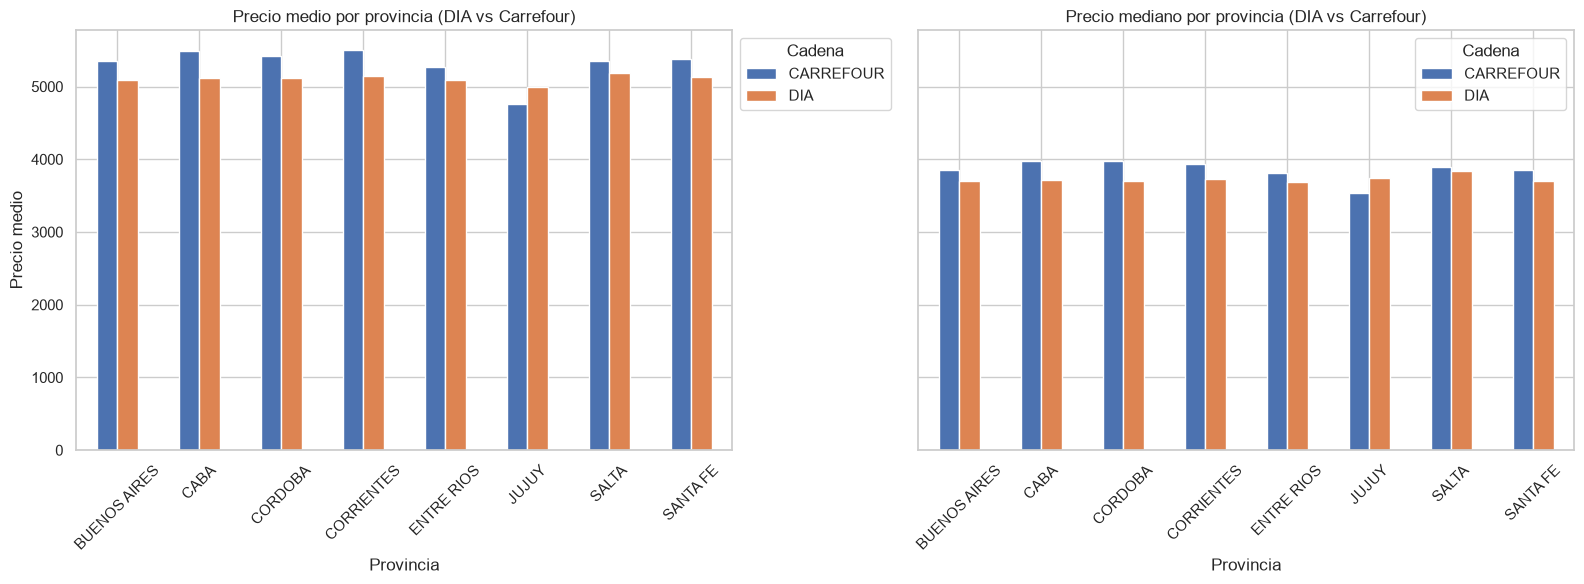

In [18]:
# Preparamos tablas para media y mediana
tabla_media = resumen_exploratorio.pivot(index='provincia',
                                         columns='cadena',
                                         values='precio_medio').sort_index()

tabla_mediana = resumen_exploratorio.pivot(index='provincia',
                                           columns='cadena',
                                           values='precio_mediano').sort_index()

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# --- Gráfico de medias ---
tabla_media.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Precio medio por provincia (DIA vs Carrefour)')
axes[0].set_xlabel('Provincia')
axes[0].set_ylabel('Precio medio')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Cadena', loc='upper left', bbox_to_anchor=(1,1))

# --- Gráfico de medianas ---
tabla_mediana.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'])
axes[1].set_title('Precio mediano por provincia (DIA vs Carrefour)')
axes[1].set_xlabel('Provincia')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Cadena')

plt.tight_layout()
plt.show()


Los gráficos muestran la comparación de precios entre DIA y Carrefour utilizando dos medidas distintas: **precio medio** y **precio mediano** por provincia. Ambas métricas se calculan sobre el conjunto flexible de pares producto–provincia donde las dos cadenas tienen información disponible.

A pesar de que la media y la mediana capturan aspectos diferentes de la distribución de precios, el patrón territorial es idéntico en ambos casos:

- **En todas las provincias**, Carrefour presenta precios superiores a los de DIA.
- **La única excepción es Jujuy**, donde tanto la media como la mediana indican que **Carrefour es más barato que DIA** dentro del universo de productos comparables.

La coincidencia entre ambas métricas refuerza la solidez del resultado y sugiere que la diferencia observada en Jujuy no depende de valores extremos ni de la forma de la distribución, sino que refleja una característica territorial consistente del comportamiento de precios en esa provincia.


In [19]:
# Calculamos, dentro del universo flexible, la diferencia absoluta y porcentual entre cadenas
# y resumimos estas variaciones por provincia para evaluar el comportamiento relativo de precios.
exploracion_diferencias = pares_flexibles.copy()
exploracion_diferencias['diferencia_abs'] = exploracion_diferencias['precio_dia_prov'] - exploracion_diferencias['precio_carrefour_prov']
exploracion_diferencias['diferencia_pct'] = exploracion_diferencias['diferencia_abs'] / exploracion_diferencias['precio_carrefour_prov'] * 100
exploracion_por_provincia = (exploracion_diferencias.groupby('provincia').agg(productos_comparados=('id_producto','size'), media_diferencia_pct=('diferencia_pct','mean'), mediana_diferencia_pct=('diferencia_pct','median'), pct_dia_menor=('diferencia_pct',lambda s:(s<0).mean()*100)).sort_values('mediana_diferencia_pct'))
display(exploracion_por_provincia.round(2))

,productos_comparados,media_diferencia_pct,mediana_diferencia_pct,pct_dia_menor
provincia,,,,
CABA,2574,-4.10,-2.11,56.95
CORDOBA,2555,-2.58,-1.90,57.65
CORRIENTES,2458,-3.45,-0.94,60.66
ENTRE RIOS,2534,-0.10,-0.30,52.45
SANTA FE,2527,-1.54,-0.14,52.63
BUENOS AIRES,2618,-1.94,0.13,46.72
SALTA,2311,-0.18,0.88,43.92
JUJUY,1791,9.67,8.27,26.24


La distribución de diferencias porcentuales entre DIA y Carrefour refuerza el patrón territorial identificado en la Etapa 2. Allí se observó que Carrefour presenta una estructura de precios más dispersa entre sucursales, con promociones fuertes y puntuales que no se aplican de manera homogénea en todo el territorio. DIA, en cambio, dentro del universo de productos analizados, mantiene precios más estables y descuentos más uniformes.

Este comportamiento se refleja claramente en la tabla de diferencias porcentuales producto a producto:

En la mayoría de las provincias, la mediana de la diferencia porcentual es negativa, lo que indica que DIA es más barato que Carrefour en una proporción significativa de productos (por ejemplo, CABA −2.11%, Córdoba −1.90%, Corrientes −0.94%).

La magnitud de estas diferencias varía entre provincias, lo cual es coherente con la dispersión territorial de precios observada en Carrefour: provincias con precios más altos en Carrefour muestran diferencias porcentuales más moderadas.

En Buenos Aires y Salta, la mediana de la diferencia porcentual es levemente positiva (0.13% y 0.88%), lo que indica que la relación de precios entre cadenas es más equilibrada.

Jujuy constituye el caso más extremo, con una mediana de diferencia porcentual de 8.27% y una media de 9.67%, reflejando que Carrefour ofrece precios significativamente más bajos en esa provincia dentro del conjunto flexible de productos comparables.

La presencia de diferencias porcentuales grandes en algunas provincias y pequeñas en otras es consistente con una estrategia promocional heterogénea por parte de Carrefour, donde descuentos intensos aplicados en productos específicos o sucursales puntuales generan saltos porcentuales elevados. Por el contrario, la estabilidad relativa de las diferencias porcentuales en DIA coincide con su política de precios y descuentos más homogénea.

En conjunto, la tabla no solo complementa los gráficos de precios medios y medianos, sino que también refuerza la hipótesis de que Carrefour opera con promociones intensas y localizadas, mientras que DIA mantiene una estructura de precios más uniforme en todo el territorio.


### 4.2 Revisión y exclusión de valores atípicos

Se consideran casos atípicos los pares con `|diferencia_pct| > 500%`. Se identifican explícitamente y los productos afectados quedan fuera de los universos comparables de esta etapa, evitando que casos extremos dominen las medias.

In [20]:
# Identificamos los pares producto-provincia con diferencias porcentuales extremas (outliers)
outliers_pct = exploracion_diferencias[exploracion_diferencias['diferencia_pct'].abs() > 500].copy()
print(f'Pares producto-provincia con |diferencia_pct| > 500%: {len(outliers_pct)}')
print(f'Productos afectados: {outliers_pct["id_producto"].nunique()}')
if len(outliers_pct) > 0:
    display(outliers_pct[['provincia','id_producto','precio_dia_prov','precio_carrefour_prov','diferencia_pct']].sort_values('diferencia_pct', ascending=False).round(2))

Pares producto-provincia con |diferencia_pct| > 500%: 33
Productos afectados: 5


,provincia,id_producto,precio_dia_prov,precio_carrefour_prov,diferencia_pct
1731,BUENOS AIRES,7792180136763,1730.0,144.00,1101.39
14002,JUJUY,7792180136763,1730.0,144.00,1101.39
4320,CABA,7792180136763,1730.0,144.00,1101.39
6880,CORDOBA,7792180136763,1730.0,144.00,1101.39
11883,ENTRE RIOS,7792180136763,1730.0,144.00,1101.39
1730,BUENOS AIRES,7792180136749,1590.0,144.00,1004.17
9377,CORRIENTES,7792180136749,1590.0,144.00,1004.17
6879,CORDOBA,7792180136749,1590.0,144.00,1004.17
4319,CABA,7792180136749,1590.0,144.00,1004.17
11882,ENTRE RIOS,7792180136749,1590.0,144.00,1004.17


In [21]:
productos_atipicos = set(outliers_pct['id_producto'])
pares_limpios = exploracion_diferencias[~exploracion_diferencias['id_producto'].isin(productos_atipicos)].copy()
print(f'Productos atípicos excluidos del análisis: {len(productos_atipicos)}')
print(f'Pares antes del filtro: {len(exploracion_diferencias):,}')
print(f'Pares después del filtro: {len(pares_limpios):,}')

Productos atípicos excluidos del análisis: 5
Pares antes del filtro: 19,368
Pares después del filtro: 19,335


La detección de valores atípicos identificó **33 pares producto–provincia** con diferencias porcentuales superiores al +500%, correspondientes a **solo 5 productos**. En todos los casos, el patrón es consistente: Carrefour exhibe precios extremadamente bajos (entre 144 y 170 pesos), mientras que DIA mantiene valores regulares para esos mismos productos. Esta combinación genera diferencias relativas muy grandes que no reflejan una relación territorial típica entre cadenas.

La exclusión de estos productos es metodológicamente necesaria, ya que su presencia podría distorsionar las métricas provinciales y regionales, afectando la interpretación de las diferencias de precios. Además, estos casos refuerzan lo observado en la Etapa 2: Carrefour presenta **promociones intensas y localizadas**, aplicadas sobre productos específicos y no replicadas en todas las sucursales. DIA, en cambio, mantiene una estructura de precios más estable y homogénea, lo que evita saltos porcentuales extremos.

Con los valores atípicos removidos, el universo de productos queda depurado y listo para construir las comparaciones homogéneas de 7 y 8 provincias.


### 4.3 Cobertura completa: 8 provincias y 7 provincias sin Jujuy

Una vez excluidos los productos afectados por diferencias extremas, se construyen dos universos: **8 provincias**, con cobertura completa incluyendo Jujuy, y **7 provincias**, con cobertura completa sin exigir Jujuy. El segundo será el universo principal.

In [22]:
# Resumen de cobertura completa de productos comparables
cobertura_8 = pares_limpios.groupby('id_producto')['provincia'].nunique()
productos_cobertura_8 = set(cobertura_8[cobertura_8 == 8].index)
pares_sin_jujuy = pares_limpios[pares_limpios['provincia'] != 'JUJUY'].copy()
cobertura_7 = pares_sin_jujuy.groupby('id_producto')['provincia'].nunique()
productos_cobertura_7 = set(cobertura_7[cobertura_7 == 7].index)
print(f'Productos con cobertura completa en 8 provincias: {len(productos_cobertura_8):,}')
print(f'Productos con cobertura completa en 7 provincias: {len(productos_cobertura_7):,}')
print(f'Productos adicionales al excluir Jujuy del requisito: {len(productos_cobertura_7 - productos_cobertura_8):,}')

Productos con cobertura completa en 8 provincias: 1,662
Productos con cobertura completa en 7 provincias: 2,220
Productos adicionales al excluir Jujuy del requisito: 558


In [23]:
# Resumen de cobertura de productos comparables
cobertura_resumen = pd.DataFrame({'universo':['8 provincias','7 provincias sin Jujuy'],'provincias':[8,7],'productos_comparables':[len(productos_cobertura_8),len(productos_cobertura_7)]})
cobertura_resumen['variacion_vs_8_pct'] = (cobertura_resumen['productos_comparables']/len(productos_cobertura_8)-1)*100
display(cobertura_resumen.round(2))

,universo,provincias,productos_comparables,variacion_vs_8_pct
0,8 provincias,8,1662,0.00
1,7 provincias sin Jujuy,7,2220,33.57


## 5. Construcción de los datasets finales

Se generan dos variantes del dataset de observaciones, una para 7 provincias y otra para 8. Ambas conservan la granularidad **producto × sucursal × cadena**. La media por producto y provincia se mantiene en una tabla analítica separada, porque no es metodológicamente consistente mezclar un precio promedio provincial con coordenadas e información de una sucursal concreta.

In [24]:
# Creamos datasets finales de precios por producto y provincia, para las dos coberturas de provincias.
columnas_finales = ['id_sucursal','id_producto','productos_descripcion','productos_marca','precio_efectivo','provincia','sucursales_localidad','sucursales_latitud','sucursales_longitud','id_comercio']
dia_7 = productos_dia_geo[(productos_dia_geo['id_producto'].isin(productos_cobertura_7)) & (productos_dia_geo['provincia'] != 'JUJUY')][columnas_finales].copy(); dia_7['cadena']='DIA'
carrefour_7 = productos_carrefour_geo[(productos_carrefour_geo['id_producto'].isin(productos_cobertura_7)) & (productos_carrefour_geo['provincia'] != 'JUJUY')][columnas_finales].copy(); carrefour_7['cadena']='CARREFOUR'
dataset_precios_7 = pd.concat([dia_7,carrefour_7],ignore_index=True)
dia_8 = productos_dia_geo[productos_dia_geo['id_producto'].isin(productos_cobertura_8)][columnas_finales].copy(); dia_8['cadena']='DIA'
carrefour_8 = productos_carrefour_geo[productos_carrefour_geo['id_producto'].isin(productos_cobertura_8)][columnas_finales].copy(); carrefour_8['cadena']='CARREFOUR'
dataset_precios_8 = pd.concat([dia_8,carrefour_8],ignore_index=True)
print('dataset_precios_7:', dataset_precios_7.shape)
print('dataset_precios_8:', dataset_precios_8.shape)

dataset_precios_7: (2912838, 11)
dataset_precios_8: (2273684, 11)


In [25]:
# Creamos una función para construir las tablas analíticas de precios por producto y provincia, incluyendo la cantidad de sucursales que reportan cada producto.
def construir_precios_producto_provincia(dataset):
    return (dataset.groupby(['provincia','id_producto','cadena'],as_index=False).agg(precio_efectivo_medio=('precio_efectivo','mean'), precio_efectivo_mediano=('precio_efectivo','median'), sucursales=('id_sucursal','nunique')))
precios_producto_provincia_7 = construir_precios_producto_provincia(dataset_precios_7)
precios_producto_provincia_8 = construir_precios_producto_provincia(dataset_precios_8)
print('Tabla analítica 7 provincias:', precios_producto_provincia_7.shape)
print('Tabla analítica 8 provincias:', precios_producto_provincia_8.shape)

Tabla analítica 7 provincias: (31080, 6)
Tabla analítica 8 provincias: (26592, 6)


In [26]:
# Inspeccionamos los primeros registros de una de las tablas analíticas.
precios_producto_provincia_7.head(10)

,provincia,id_producto,cadena,precio_efectivo_medio,precio_efectivo_mediano,sucursales
0,BUENOS AIRES,40084107,CARREFOUR,2836.178344,2869.0,157
1,BUENOS AIRES,40084107,DIA,2785.654206,2785.0,428
2,BUENOS AIRES,42277057,CARREFOUR,7786.849462,7920.0,93
3,BUENOS AIRES,42277057,DIA,6455.000000,6455.0,428
4,BUENOS AIRES,75079437,CARREFOUR,18422.750000,18469.0,48
5,BUENOS AIRES,75079437,DIA,12750.000000,12750.0,428
6,BUENOS AIRES,75082734,CARREFOUR,8014.716418,8049.0,134
7,BUENOS AIRES,75082734,DIA,8020.869159,8019.0,428
8,BUENOS AIRES,75083694,CARREFOUR,8757.762712,8709.0,59
9,BUENOS AIRES,75083694,DIA,8701.032710,8699.0,428


In [27]:
# Exportamos los datasets finales a parquet para su uso en la Etapa 4
dataset_precios_7.to_parquet('../data/processed/dataset_precios_7_provincias.parquet', index=False)
dataset_precios_8.to_parquet('../data/processed/dataset_precios_8_provincias.parquet', index=False)
precios_producto_provincia_7.to_parquet('../data/processed/precios_producto_provincia_7.parquet', index=False)
precios_producto_provincia_8.to_parquet('../data/processed/precios_producto_provincia_8.parquet', index=False)
print('Datasets guardados en ../data/processed/')

Datasets guardados en ../data/processed/


La construcción de los datasets finales completa la preparación del universo territorial depurado. En esta etapa se generaron dos estructuras complementarias:

dataset_precios_7 y dataset_precios_8, que conservan la granularidad completa a nivel sucursal y permiten analizar la distribución territorial de precios, la variabilidad entre sucursales y la cobertura efectiva de cada cadena en cada provincia.

precios_producto_provincia_7 y precios_producto_provincia_8, que agregan la información a nivel provincia y resumen el comportamiento de cada producto mediante precios medios, medianos y cantidad de sucursales que lo comercializan. Estas tablas constituyen la base analítica para comparar precios entre cadenas de manera homogénea y construir indicadores territoriales consistentes.

Con ambos datasets generados y guardados, la etapa territorial queda completamente preparada para avanzar hacia el análisis comparativo entre provincias y regiones, evaluar patrones de precios y profundizar en las diferencias estructurales entre DIA y Carrefour.


## 6. Distribución territorial de sucursales

Antes de interpretar diferencias provinciales, se observa cuántas sucursales sostienen cada comparación. La cantidad de sucursales no determina por sí sola el precio, pero permite contextualizar la cobertura de cada cadena.

In [28]:
# Cobertura de sucursales por cadena y provincia
print('Sucursales únicas por cadena (7 provincias):')
print(dataset_precios_7.groupby('cadena')['id_sucursal'].nunique())
sucursales_prov_cadena = dataset_precios_7.groupby(['provincia','cadena'])['id_sucursal'].nunique().reset_index()
display(sucursales_prov_cadena.pivot(index='provincia',columns='cadena',values='id_sucursal'))

Sucursales únicas por cadena (7 provincias):
cadena
CARREFOUR    632
DIA          976
Name: id_sucursal, dtype: int64


cadena,CARREFOUR,DIA
provincia,,
BUENOS AIRES,160,428
CABA,365,432
CORDOBA,82,3
CORRIENTES,2,15
ENTRE RIOS,12,65
SALTA,5,24
SANTA FE,6,9


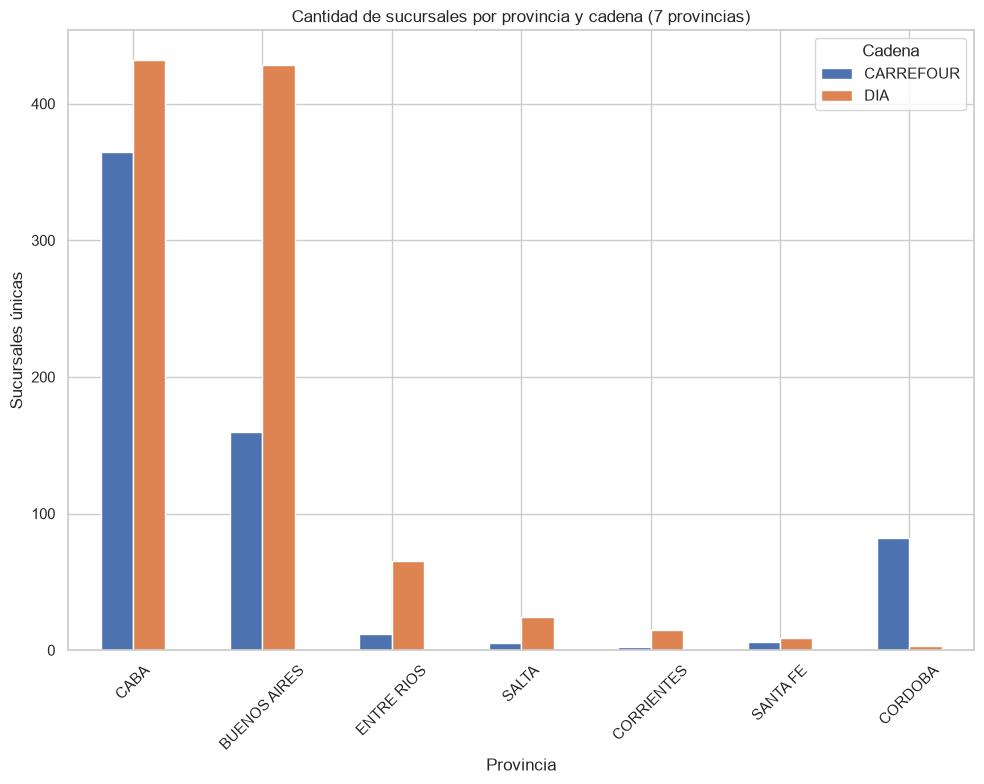

In [29]:
# Gráfico de barras de sucursales por provincia y cadena
pivot_suc = sucursales_prov_cadena.pivot(index='provincia',columns='cadena',values='id_sucursal')
fig,ax=plt.subplots(figsize=(10,8)); pivot_suc.sort_values('DIA',ascending=False).plot(kind='bar',ax=ax)
ax.set_title('Cantidad de sucursales por provincia y cadena (7 provincias)'); ax.set_xlabel('Provincia'); 
ax.set_ylabel('Sucursales únicas'); ax.tick_params(axis='x',rotation=45); ax.legend(title='Cadena'); plt.tight_layout(); plt.show()

La distribución territorial es desigual. Las provincias con muy pocas sucursales de una cadena deben interpretarse con mayor cautela. El análisis de precios se realiza sobre productos comparables y no sobre un promedio ponderado por cantidad de sucursales.

## 7. Nivel medio de precios por provincia, universo flexible

Una vez realizada la exploración inicial del punto 4 y excluidos los productos afectados por diferencias extremas (`|diferencia_pct| > 500%`), se utiliza el dataset `pares_limpios` para analizar el nivel medio de precios por provincia.

En este punto se mantiene la **misma metodología utilizada en el punto 4**:

- se trabaja con un **universo flexible**;
- no se exige que un producto esté presente en todas las provincias;
- se compara únicamente cuando el producto está disponible en ambas cadenas dentro de una misma provincia;
- primero se calcula el precio medio del producto dentro de cada provincia y cadena;
- posteriormente se obtiene la media y la mediana de esos precios a nivel provincial.

De esta manera, **cada producto tiene el mismo peso dentro de una provincia**, independientemente de la cantidad de sucursales en las que se encuentre disponible.

A diferencia del análisis principal de comparación entre cadenas desarrollado posteriormente, en este punto se incluyen las **8 provincias disponibles en el universo geográfico común**, incluyendo Jujuy.

El objetivo es obtener una visión territorial completa del nivel medio de precios de cada cadena antes de pasar a los análisis que requieren un universo de productos con cobertura completa.

***Metodología de cálculo*** para cada combinación:

provincia + id_producto + cadena


In [30]:
# Cada producto tiene el mismo peso dentro de cada provincia.
pares_8_flexible = pares_limpios.copy()

# Transformamos las columnas de precios a formato largo
precios_8_flexible = pares_8_flexible.melt(
    id_vars=['provincia', 'id_producto'],
    value_vars=['precio_dia_prov', 'precio_carrefour_prov'],
    var_name='cadena',
    value_name='precio_producto_prov'
)

# Convertimos nombres de columnas a nombres de cadenas
precios_8_flexible['cadena'] = precios_8_flexible['cadena'].map({
    'precio_dia_prov': 'DIA',
    'precio_carrefour_prov': 'CARREFOUR'
})

# Calculamos nivel medio y mediana provincial
resumen_precios_8 = precios_8_flexible.groupby(['provincia', 'cadena'])['precio_producto_prov'] \
    .agg(productos_comparables='count', precio_medio='mean', precio_mediano='median') \
    .reset_index()

# Comparación de medias DIA vs CARREFOUR
comparacion_precios_8 = resumen_precios_8.pivot(index='provincia', columns='cadena', values='precio_medio')
comparacion_precios_8['diferencia_pct'] = (comparacion_precios_8['DIA'] - comparacion_precios_8['CARREFOUR']) / comparacion_precios_8['CARREFOUR'] * 100

# Comparación de medianas DIA vs CARREFOUR
comparacion_mediana_8 = resumen_precios_8.pivot(index='provincia', columns='cadena', values='precio_mediano')
comparacion_mediana_8['diferencia_pct_mediana'] = (comparacion_mediana_8['DIA'] - comparacion_mediana_8['CARREFOUR']) / comparacion_mediana_8['CARREFOUR'] * 100

# Resultados
print("### Nivel medio de precios — universo flexible, 8 provincias")
display(resumen_precios_8.sort_values(['provincia', 'cadena']).round(2))

print("### Comparación de medias DIA vs CARREFOUR")
display(comparacion_precios_8.round(2))

print("### Comparación de medianas DIA vs CARREFOUR")
display(comparacion_mediana_8.round(2))

### Nivel medio de precios — universo flexible, 8 provincias


,provincia,cadena,productos_comparables,precio_medio,precio_mediano
0,BUENOS AIRES,CARREFOUR,2613,5362.60,3867.11
1,BUENOS AIRES,DIA,2613,5090.94,3700.86
2,CABA,CARREFOUR,2570,5493.11,3987.48
3,CABA,DIA,2570,5125.34,3720.00
4,CORDOBA,CARREFOUR,2550,5428.62,3981.79
5,CORDOBA,DIA,2550,5122.80,3700.00
6,CORRIENTES,CARREFOUR,2454,5505.02,3945.50
7,CORRIENTES,DIA,2454,5154.72,3730.00
8,ENTRE RIOS,CARREFOUR,2529,5284.00,3810.45
9,ENTRE RIOS,DIA,2529,5103.19,3693.57


### Comparación de medias DIA vs CARREFOUR


cadena,CARREFOUR,DIA,diferencia_pct
provincia,,,
BUENOS AIRES,5362.60,5090.94,-5.07
CABA,5493.11,5125.34,-6.70
CORDOBA,5428.62,5122.80,-5.63
CORRIENTES,5505.02,5154.72,-6.36
ENTRE RIOS,5284.00,5103.19,-3.42
JUJUY,4759.10,4991.47,4.88
SALTA,5359.54,5187.37,-3.21
SANTA FE,5389.65,5138.23,-4.66


### Comparación de medianas DIA vs CARREFOUR


cadena,CARREFOUR,DIA,diferencia_pct_mediana
provincia,,,
BUENOS AIRES,3867.11,3700.86,-4.30
CABA,3987.48,3720.00,-6.71
CORDOBA,3981.79,3700.00,-7.08
CORRIENTES,3945.50,3730.00,-5.46
ENTRE RIOS,3810.45,3693.57,-3.07
JUJUY,3539.00,3750.00,5.96
SALTA,3906.25,3833.25,-1.87
SANTA FE,3858.33,3720.00,-3.59


### Interpretación de los resultados provinciales

El análisis utiliza un **universo flexible de productos comparables**, incluyendo las 8 provincias disponibles en el estudio. Para cada combinación de producto, provincia y cadena se obtiene primero un precio medio a partir de las sucursales disponibles. Luego, cada producto recibe el mismo peso al calcular el nivel medio provincial.
De esta manera, el resultado no está dominado por las provincias o cadenas que poseen una mayor cantidad de sucursales.

***Diferencia de precios entre cadenas***

En 7 de las 8 provincias analizadas, **DIA presenta un precio medio inferior al de Carrefour**:

| Provincia | DIA | Carrefour | Diferencia |
|---|---:|---:|---:|
| Corrientes | $5.154,72 | $5.505,02 | **−6,36%** |
| CABA | $5.125,34 | $5.493,11 | **−6,70%** |
| Córdoba | $5.122,80 | $5.428,62 | **−5,63%** |
| Buenos Aires | $5.090,94 | $5.362,60 | **−5,07%** |
| Santa Fe | $5.138,23 | $5.389,65 | **−4,66%** |
| Entre Ríos | $5.103,19 | $5.284,00 | **−3,42%** |
| Salta | $5.187,37 | $5.359,54 | **−3,21%** |
| Jujuy | $4.991,47 | $4.759,10 | **+4,88%** |

La diferencia porcentual se calcula tomando a Carrefour como referencia:
`Diferencia % = (Precio_DIA - Precio_Carrefour) / Precio_Carrefour * 100`

Por lo tanto, los valores negativos indican un precio medio inferior en DIA, mientras que los positivos indican un precio medio inferior en Carrefour.
En **CABA** se observa la mayor diferencia favorable a DIA, con un precio medio **6,70% inferior** al de Carrefour. Le siguen Corrientes (−6,36%) y Córdoba (−5,63%).
En el extremo opuesto aparece **Jujuy**, donde el comportamiento se invierte: el precio medio de DIA resulta **4,88% superior** al de Carrefour.
Este comportamiento diferencia claramente a Jujuy del resto de las provincias y constituye un elemento relevante para los análisis posteriores.

***Media y mediana***

La comparación entre media y mediana permite evaluar si las diferencias observadas dependen fuertemente de la distribución de precios.
En términos generales, ambas medidas muestran un patrón similar: DIA presenta valores inferiores a Carrefour en las mismas 7 provincias y Jujuy mantiene el comportamiento contrario.
Las diferencias según la mediana son:

- CABA: **−6,71%**
- Córdoba: **−7,08%**
- Corrientes: **−5,46%**
- Buenos Aires: **−4,30%**
- Santa Fe: **−3,59%**
- Entre Ríos: **−3,07%**
- Salta: **−1,87%**
- Jujuy: **+5,96%**

La coincidencia en el sentido de las diferencias entre media y mediana aporta estabilidad descriptiva al resultado. Sin embargo, la media continuará utilizándose como **medida principal**, ya que permite mantener una metodología uniforme con los análisis posteriores basados en precios medios.

***Nivel absoluto de precios***

El nivel de precios también presenta diferencias territoriales.
Para DIA, el precio medio más elevado se observa en **Salta ($5.187,37)**, seguido por Corrientes ($5.154,72), Santa Fe ($5.138,23), CABA ($5.125,34) y Córdoba ($5.122,80).
Para Carrefour, el valor más elevado corresponde a **Corrientes ($5.505,02)**, seguido por CABA ($5.493,11) y Córdoba ($5.428,62).
En ambos casos, **Jujuy presenta el menor precio medio absoluto** de las ocho provincias para Carrefour ($4.759,10) y un valor relativamente bajo para DIA ($4.991,47). Esto muestra que un menor nivel absoluto de precios en una provincia no implica necesariamente que una determinada cadena sea la más económica frente a su competidor.
Por este motivo, en los análisis posteriores será necesario distinguir entre:
1. el **nivel absoluto de precios de una provincia**, y
2. la **diferencia relativa entre cadenas dentro de esa provincia**.

El análisis provincial con universo flexible muestra un patrón general en el que **DIA presenta precios medios inferiores a Carrefour en 7 de las 8 provincias**, mientras que Jujuy constituye la única excepción.
La diferencia entre cadenas alcanza sus mayores valores favorables a DIA en CABA, Corrientes y Córdoba. Jujuy, en cambio, presenta una inversión del patrón, con Carrefour por debajo de DIA tanto en la media como en la mediana.
Estos resultados justifican mantener a **Jujuy identificada como un caso particular** y analizar posteriormente qué ocurre cuando se exige una cobertura territorial homogénea entre las provincias.

### 7.1 Ranking provincial de precios por cadena

A partir de los precios medios calculados en el punto 7 se construye un ranking independiente para DIA y Carrefour.
El criterio de ordenamiento es el **precio medio de los productos comparables dentro de cada provincia**, utilizando exactamente la misma metodología del punto anterior.
Se construyen dos rankings independientes:
1. **DIA:** de la provincia más barata a la más cara.
2. **Carrefour:** de la provincia más barata a la más cara.

El objetivo es identificar si las dos cadenas presentan un comportamiento territorial similar o si las provincias ocupan posiciones diferentes dentro de cada cadena.
El ranking debe interpretarse como una comparación del **nivel medio de precios** de los productos comparables disponibles en cada provincia.
No implica que todos los productos sean más baratos en la provincia ubicada en la primera posición.
Además, al utilizar un universo flexible, la cantidad de productos comparables puede variar entre provincias. Por este motivo, el ranking describe el comportamiento territorial del conjunto de productos comparables disponible en cada territorio y no una canasta idéntica entre las ocho provincias.

In [31]:
# Ranking DIA
ranking_dia_8 = resumen_precios_8[resumen_precios_8['cadena'] == 'DIA'] \
    .sort_values('precio_medio', ascending=True) \
    .reset_index(drop=True)

ranking_dia_8['ranking'] = range(1, len(ranking_dia_8) + 1)

ranking_dia_8 = ranking_dia_8[['ranking', 'provincia', 'productos_comparables',
                               'precio_medio', 'precio_mediano']]

# Ranking Carrefour
ranking_carrefour_8 = resumen_precios_8[resumen_precios_8['cadena'] == 'Carrefour'] \
    .sort_values('precio_medio', ascending=True) \
    .reset_index(drop=True)

ranking_carrefour_8['ranking'] = range(1, len(ranking_carrefour_8) + 1)

ranking_carrefour_8 = ranking_carrefour_8[['ranking', 'provincia', 'productos_comparables',
                                           'precio_medio', 'precio_mediano']]

print("### Ranking DIA — de menor a mayor precio medio")
display(ranking_dia_8.round(2))

print("### Ranking Carrefour — de menor a mayor precio medio")
display(ranking_carrefour_8.round(2))

### Ranking DIA — de menor a mayor precio medio


,ranking,provincia,productos_comparables,precio_medio,precio_mediano
0,1,JUJUY,1789,4991.47,3750.00
1,2,BUENOS AIRES,2613,5090.94,3700.86
2,3,ENTRE RIOS,2529,5103.19,3693.57
3,4,CORDOBA,2550,5122.80,3700.00
4,5,CABA,2570,5125.34,3720.00
5,6,SANTA FE,2523,5138.23,3720.00
6,7,CORRIENTES,2454,5154.72,3730.00
7,8,SALTA,2307,5187.37,3833.25


### Ranking Carrefour — de menor a mayor precio medio


,ranking,provincia,productos_comparables,precio_medio,precio_mediano


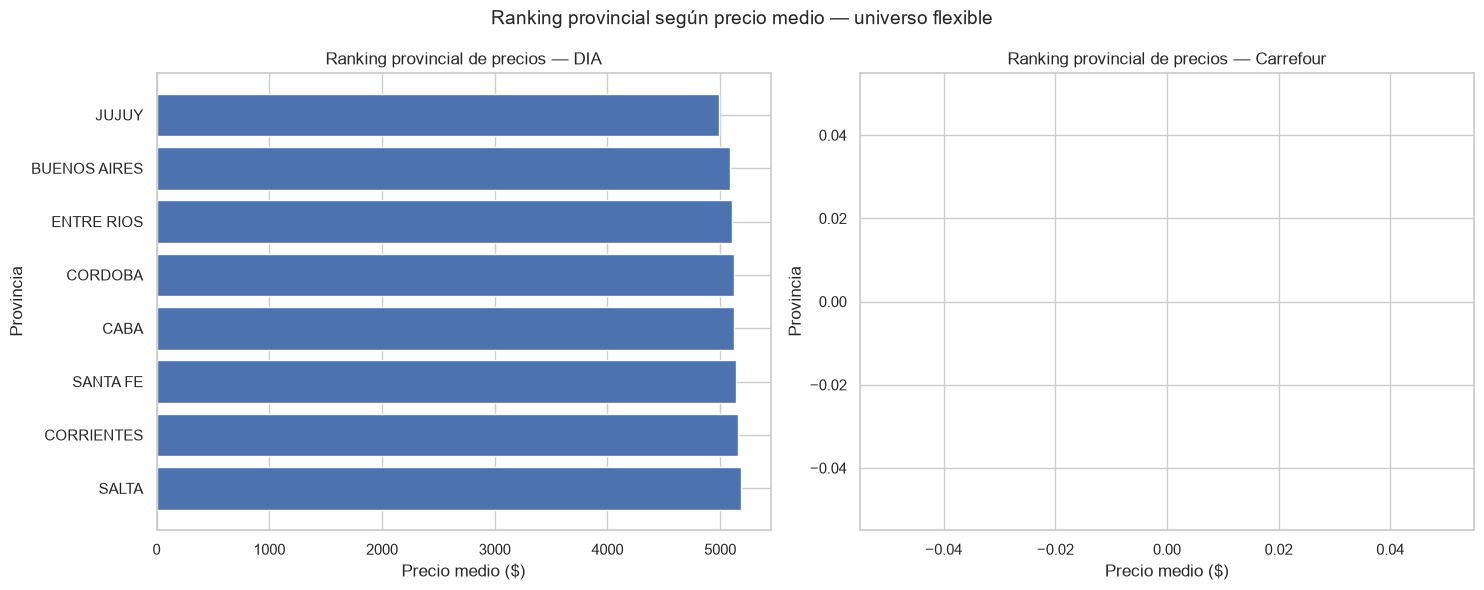

In [32]:
# Gráfico — Ranking provincial de precios
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# DIA
dia_grafico = ranking_dia_8.sort_values('precio_medio', ascending=False)
axes[0].barh(dia_grafico['provincia'], dia_grafico['precio_medio'])
axes[0].set_title('Ranking provincial de precios — DIA')
axes[0].set_xlabel('Precio medio ($)')
axes[0].set_ylabel('Provincia')

# Carrefour
carrefour_grafico = ranking_carrefour_8.sort_values('precio_medio', ascending=False)
axes[1].barh(carrefour_grafico['provincia'], carrefour_grafico['precio_medio'])
axes[1].set_title('Ranking provincial de precios — Carrefour')
axes[1].set_xlabel('Precio medio ($)')
axes[1].set_ylabel('Provincia')

plt.suptitle('Ranking provincial según precio medio — universo flexible', fontsize=14)
plt.tight_layout()
plt.show()

El gráfico presenta dos rankings provinciales construidos a partir del **precio medio del universo flexible de productos comparables**. Las provincias se ordenan de menor a mayor precio medio para cada cadena por separado.

**Ranking de DIA**
Jujuy presenta el menor precio medio de DIA, con **$4.991,47**, mientras que Salta presenta el mayor, con **$5.187,37**.
La diferencia entre ambos extremos es de aproximadamente **$195,90**, lo que representa una variación cercana al **3,9%** respecto del valor de Jujuy.

**Ranking de Carrefour**
En esta cadena, Jujuy también presenta el menor precio medio (**$4.759,10**), mientras que Corrientes registra el mayor (**$5.505,02**).
La diferencia entre ambos extremos alcanza aproximadamente **$745,92**, equivalente a un **15,7%** respecto del precio medio de Jujuy.

Los rankings muestran que el orden territorial de los precios **no es idéntico entre las dos cadenas**.
Jujuy ocupa el primer lugar en ambas, es decir, presenta el menor precio medio tanto para DIA como para Carrefour. Sin embargo, a partir de allí aparecen diferencias importantes.
**Por ejemplo:**

- **Buenos Aires** ocupa el segundo lugar en DIA, pero el cuarto en Carrefour.
- **Salta** ocupa el último lugar en DIA, pero el tercero en Carrefour.
- **Corrientes** ocupa el séptimo lugar en DIA y el último en Carrefour.
- **Córdoba** ocupa el cuarto lugar en DIA y el sexto en Carrefour.
- **CABA** ocupa el quinto lugar en DIA y el séptimo en Carrefour.

Esto indica que el nivel territorial de precios **no sigue exactamente el mismo patrón en ambas cadenas**.

El ranking también muestra una mayor amplitud territorial en Carrefour. Entre la provincia con menor y mayor precio medio existe una diferencia aproximada de **15,7%**, mientras que en DIA la diferencia es cercana al **3,9%**.
Por lo tanto, dentro de este universo flexible, los precios medios de DIA presentan un comportamiento territorial más concentrado, mientras que Carrefour muestra diferencias más marcadas entre provincias.
Este resultado es **descriptivo** y no permite establecer por sí solo las causas de las diferencias territoriales. La mayor amplitud observada en Carrefour debe interpretarse como una característica de la distribución de precios obtenida en este análisis, sin atribuirla a una causa específica.

Como conclusión del punto 7.1, el ranking confirma que existe una **diferenciación territorial de precios** y que su intensidad varía entre cadenas.
DIA presenta una distribución provincial relativamente más homogénea, mientras que Carrefour muestra una mayor distancia entre sus provincias de menor y mayor precio medio.
Además, aunque **Jujuy es la provincia con menor precio medio en ambas cadenas**, esto no significa que DIA sea más barata allí: como se observó en el punto 7, **Carrefour presenta en Jujuy un precio medio inferior al de DIA**.
Por este motivo, el ranking provincial debe analizarse conjuntamente con la comparación directa entre cadenas realizada en el punto 7.

## 8. Comparación producto a producto

Para cada `provincia + id_producto` se compara el precio promedio observado en DIA con el de Carrefour. La diferencia porcentual se expresa respecto del precio de Carrefour: `diferencia_pct = (precio_DIA - precio_Carrefour) / precio_Carrefour × 100`. Negativo significa DIA más barato; positivo, Carrefour más barato. La media es la medida principal y la mediana funciona como control de robustez.

In [33]:
# Función para calcular la diferencia porcentual DIA–Carrefour por producto y provincia
# dentro del universo homogéneo, generando una tabla comparativa limpia y depurada.
def construir_comparacion(precios_producto_provincia,provincias):
    tabla=precios_producto_provincia[precios_producto_provincia['provincia'].isin(provincias)].copy()
    medio=(tabla.pivot_table(index=['provincia','id_producto'],columns='cadena',values='precio_efectivo_medio',aggfunc='first').dropna(subset=['DIA','CARREFOUR']).reset_index().rename(columns={'DIA':'precio_dia_prov','CARREFOUR':'precio_carrefour_prov'}))
    medio['diferencia_abs']=medio['precio_dia_prov']-medio['precio_carrefour_prov']
    medio['diferencia_pct']=medio['diferencia_abs']/medio['precio_carrefour_prov']*100
    return medio
provincias_7=sorted(dataset_precios_7['provincia'].unique()); provincias_8=sorted(dataset_precios_8['provincia'].unique())
comparacion_7=construir_comparacion(precios_producto_provincia_7,provincias_7); comparacion_8=construir_comparacion(precios_producto_provincia_8,provincias_8)
print('Comparaciones producto-provincia — 7 provincias:',len(comparacion_7)); print('Comparaciones producto-provincia — 8 provincias:',len(comparacion_8))

Comparaciones producto-provincia — 7 provincias: 15540
Comparaciones producto-provincia — 8 provincias: 13296


In [34]:
# Función para resumir las diferencias provinciales, obteniendo media, mediana y
# proporción de productos donde DIA resulta más barato en el universo homogéneo.
def resumen_dif(comparacion):
    return comparacion.groupby('provincia').agg(productos_comparados=('id_producto','size'),media_diferencia_pct=('diferencia_pct','mean'),mediana_diferencia_pct=('diferencia_pct','median'),pct_dia_menor=('diferencia_pct',lambda s:(s<0).mean()*100),pct_carrefour_menor=('diferencia_pct',lambda s:(s>0).mean()*100))
resumen_diferencias_7=resumen_dif(comparacion_7); resumen_diferencias_8=resumen_dif(comparacion_8)
print('Diferencias — 7 provincias'); display(resumen_diferencias_7.round(2)); print('Diferencias — 8 provincias'); display(resumen_diferencias_8.round(2))

Diferencias — 7 provincias


,productos_comparados,media_diferencia_pct,mediana_diferencia_pct,pct_dia_menor,pct_carrefour_menor
provincia,,,,,
BUENOS AIRES,2220,-3.49,0.13,47.48,52.21
CABA,2220,-5.52,-2.66,60.59,37.97
CORDOBA,2220,-4.34,-2.44,59.46,39.46
CORRIENTES,2220,-4.59,-0.95,61.26,34.37
ENTRE RIOS,2220,-1.67,-0.33,52.66,45.63
SALTA,2220,-1.42,0.88,44.68,54.91
SANTA FE,2220,-2.52,-0.21,53.20,42.79


Diferencias — 8 provincias


,productos_comparados,media_diferencia_pct,mediana_diferencia_pct,pct_dia_menor,pct_carrefour_menor
provincia,,,,,
BUENOS AIRES,1662,-3.24,0.40,45.55,54.45
CABA,1662,-5.76,-2.89,64.62,34.96
CORDOBA,1662,-4.48,-3.31,61.31,38.21
CORRIENTES,1662,-4.66,-0.93,61.31,35.44
ENTRE RIOS,1662,-0.90,0.00,48.68,49.64
JUJUY,1662,8.45,8.28,26.84,70.04
SALTA,1662,-1.27,0.88,44.58,55.11
SANTA FE,1662,-2.11,-0.18,52.47,44.10


Los resultados del punto 8 muestran, para cada provincia, cómo se comportan las diferencias de precios entre DIA y Carrefour dentro del universo homogéneo. La columna **media_diferencia_pct** indica el promedio de la diferencia porcentual producto a producto: valores negativos significan que, en promedio, DIA es más barato. En las 7 provincias, la media es negativa en todas, y al incorporar Jujuy en el universo de 8 provincias, esta provincia invierte el patrón con una media positiva. La **mediana_diferencia_pct** refleja el comportamiento central de la distribución: con 7 provincias, la mediana es mayormente negativa, pero al sumar Jujuy la relación se equilibra y algunas provincias quedan cerca de cero o levemente positivas. Las columnas **pct_dia_menor** y **pct_carrefour_menor** muestran el porcentaje de productos donde cada cadena resulta más barata; en la mayoría de las provincias los valores están relativamente equilibrados, salvo en Jujuy, donde Carrefour domina claramente. En conjunto, estas métricas permiten evaluar la diferencia relativa entre cadenas de forma limpia y comparable, sin la distorsión del universo flexible.


## 9. Diferencias territoriales y comportamiento de los mismos productos

Este punto analiza si un mismo producto mantiene un precio consistente entre provincias dentro de cada cadena o si presenta variaciones territoriales significativas. Para ello se calcula, para cada producto, el recorrido provincial de su precio promedio dentro de cada cadena, obteniendo el rango absoluto y porcentual entre el valor mínimo y máximo observado. Esta medida permite evaluar la estabilidad territorial de los precios y comparar la homogeneidad de las políticas de cada cadena en el universo homogéneo.


In [35]:
# Calculamos la variación territorial de precios por producto y cadena,
# midiendo cuánto cambia el precio de un mismo producto entre provincias
# y resumiendo esa dispersión mediante rangos absolutos y porcentuales.
def variacion_territorial_productos(precios_producto_provincia,provincias):
    tabla=precios_producto_provincia[precios_producto_provincia['provincia'].isin(provincias)].copy()
    r=tabla.groupby(['cadena','id_producto'])['precio_efectivo_medio'].agg(['min','max','mean','median','count']).reset_index()
    r['rango_abs']=r['max']-r['min']; 
    r['rango_pct']=np.where(r['max']>0,r['rango_abs']/r['max']*100,np.nan); 
    return r
variacion_7=variacion_territorial_productos(precios_producto_provincia_7,provincias_7)
resumen_dispersion=variacion_7.groupby('cadena').agg(productos=('id_producto','nunique'),rango_pct_mediano=('rango_pct','median'),rango_pct_medio=('rango_pct','mean'))
display(resumen_dispersion.round(2))

,productos,rango_pct_mediano,rango_pct_medio
cadena,,,
CARREFOUR,2220,9.21,11.45
DIA,2220,3.61,3.48


La tabla resume la dispersión territorial de precios por cadena dentro del universo homogéneo de 7 provincias. Cada valor refleja cuánto varía el precio de un mismo producto entre provincias. Carrefour y DIA tienen la misma cantidad de productos comparables, pero muestran comportamientos distintos: el rango porcentual mediano de Carrefour (9.21%) es más del doble que el de DIA (3.61%), y su promedio también es mayor (11.45% vs. 3.48%). Esto indica que los precios de Carrefour presentan una variación territorial significativamente más alta, mientras que los de DIA son más estables entre provincias. En conjunto, la dispersión de DIA es baja y consistente, mientras que la de Carrefour es más amplia y heterogénea.


In [36]:
# Calcula la dispersión de precios entre sucursales para cada producto,
# y resume por provincia y cadena la variación porcentual interna (rango_pct).
dispersion_sucursal=(dataset_precios_7.groupby(['provincia','cadena','id_producto'])['precio_efectivo'].agg(['min','max','mean']).reset_index())
dispersion_sucursal['rango_pct']=np.where(dispersion_sucursal['max']>0,(dispersion_sucursal['max']-dispersion_sucursal['min'])/dispersion_sucursal['max']*100,np.nan)
resumen_dispersion_prov=dispersion_sucursal.groupby(['provincia','cadena'])['rango_pct'].median().reset_index(name='rango_pct_mediano')
display(resumen_dispersion_prov.pivot(index='provincia',columns='cadena',values='rango_pct_mediano').round(2))

cadena,CARREFOUR,DIA
provincia,,
BUENOS AIRES,16.20,1.95
CABA,9.73,1.95
CORDOBA,12.27,0.00
CORRIENTES,0.00,0.00
ENTRE RIOS,7.96,0.00
SALTA,0.99,3.20
SANTA FE,5.07,0.00


La tabla muestra la dispersión interna de precios entre sucursales para cada cadena dentro de cada provincia. El indicador utilizado es el rango porcentual mediano, que refleja cuánto varía el precio de un mismo producto dentro de la provincia. Valores más altos indican mayor heterogeneidad entre sucursales; valores más bajos, mayor consistencia interna. Este análisis complementa la dispersión territorial entre provincias: mientras el punto anterior medía variación macro (entre provincias), aquí se observa la variación micro dentro de cada provincia. La comparación entre cadenas permite identificar cuál presenta políticas de precios más homogéneas a nivel local.


**El `rango_pct` se interpreta como una medida descriptiva de dispersión: `(máximo − mínimo) / máximo × 100`. No identifica por sí mismo la causa de la variación.**

## 10. Análisis por regiones

Para complementar el análisis provincial, se agrupan las ocho provincias en tres regiones:

| Región | Provincias |
|---|---|
| **METROPOLITANA** | Buenos Aires, CABA |
| **CENTRO–LITORAL** | Córdoba, Santa Fe, Entre Ríos, Corrientes |
| **NOA** | Jujuy, Salta |

El análisis regional utiliza el universo de **8 provincias** (`precios_producto_provincia_8`) porque la definición del NOA incluye Jujuy. Para evitar que una región pese más por tener más sucursales o más observaciones, primero se calcula el precio medio de cada producto dentro de cada provincia y luego se promedian esas provincias dentro de cada región. De esta forma, cada provincia tiene el mismo peso dentro de su región.

La comparación entre regiones se realiza sobre los mismos productos del universo de 8 provincias. Así se puede evaluar tanto qué región presenta menores niveles de precios como las diferencias entre DIA y Carrefour.


In [37]:
# Definimos la correspondencia provincia - región
regiones = {
    'METROPOLITANA': ['BUENOS AIRES', 'CABA'],
    'CENTRO-LITORAL': ['CORDOBA', 'SANTA FE', 'ENTRE RIOS', 'CORRIENTES'],
    'NOA': ['JUJUY', 'SALTA']
}

mapa_region = {
    provincia: region
    for region, provincias in regiones.items()
    for provincia in provincias
}

precios_region = precios_producto_provincia_8.copy()
precios_region['region'] = precios_region['provincia'].map(mapa_region)

# Control: todas las provincias del universo de 8 deben quedar asignadas.
print('Provincias sin región:', precios_region.loc[precios_region['region'].isna(), 'provincia'].unique())

# Cada producto y cadena debe estar presente en todas las provincias que componen su región.
cobertura_region = (
    precios_region
    .groupby(['region', 'id_producto', 'cadena'])['provincia']
    .nunique()
    .reset_index(name='provincias_observadas')
)

tamanio_region = {region: len(provincias) for region, provincias in regiones.items()}
cobertura_region['provincias_esperadas'] = cobertura_region['region'].map(tamanio_region)

print('¿Cobertura regional completa?:',
      (cobertura_region['provincias_observadas'] == cobertura_region['provincias_esperadas']).all())

display(cobertura_region.groupby(['region', 'provincias_observadas']).size().rename('combinaciones').reset_index())


Provincias sin región: <ArrowStringArray>
[]
Length: 0, dtype: str
¿Cobertura regional completa?: True


,region,provincias_observadas,combinaciones
0,CENTRO-LITORAL,4,3324
1,METROPOLITANA,2,3324
2,NOA,2,3324


La salida muestra que cada región tiene **cobertura completa**: todos los productos del universo de 8 provincias aparecen en todas las provincias que componen su región, tanto para DIA como para Carrefour. Por eso cada región registra **3324 combinaciones**, que corresponden a los **1662 productos** del universo homogéneo multiplicados por las **2 cadenas**. Esto confirma que el análisis regional puede hacerse sin sesgos, con igual peso por provincia y sin faltantes en ninguna región.


In [38]:
# Precio regional por producto y cadena.
# Primero se toma el precio medio provincial y luego se promedian las provincias,
# dando el mismo peso a cada provincia dentro de su región.

precios_producto_region = (
    precios_region
    .groupby(['region', 'id_producto', 'cadena'], as_index=False)
    .agg(
        precio_region_medio=('precio_efectivo_medio', 'mean'),
        precio_region_mediano=('precio_efectivo_medio', 'median'),
        provincias=('provincia', 'nunique')
    )
)

# Comparamos DIA y Carrefour para cada producto dentro de cada región.
comparacion_region = (
    precios_producto_region
    .pivot_table(
        index=['region', 'id_producto'],
        columns='cadena',
        values='precio_region_medio',
        aggfunc='first'
    )
    .dropna(subset=['DIA', 'CARREFOUR'])
    .reset_index()
    .rename(columns={
        'DIA': 'precio_dia_region',
        'CARREFOUR': 'precio_carrefour_region'
    })
)

comparacion_region['diferencia_abs'] = (
    comparacion_region['precio_dia_region']
    - comparacion_region['precio_carrefour_region']
)

comparacion_region['diferencia_pct'] = (
    comparacion_region['diferencia_abs']
    / comparacion_region['precio_carrefour_region']
    * 100
)

resumen_regional = (
    comparacion_region
    .groupby('region')
    .agg(
        productos_comparados=('id_producto', 'size'),
        precio_medio_DIA=('precio_dia_region', 'mean'),
        precio_medio_Carrefour=('precio_carrefour_region', 'mean'),
        diferencia_media_pct=('diferencia_pct', 'mean'),
        diferencia_mediana_pct=('diferencia_pct', 'median'),
        pct_DIA_mas_barato=('diferencia_pct', lambda s: (s < 0).mean() * 100),
        pct_Carrefour_mas_barato=('diferencia_pct', lambda s: (s > 0).mean() * 100)
    )
    .sort_values('precio_medio_DIA')
)

display(resumen_regional.round(2))


,productos_comparados,precio_medio_DIA,precio_medio_Carrefour,diferencia_media_pct,diferencia_mediana_pct,pct_DIA_mas_barato,pct_Carrefour_mas_barato
region,,,,,,,
CENTRO-LITORAL,1662,4895.57,5136.69,-3.34,-0.47,55.05,44.89
METROPOLITANA,1662,4898.10,5199.96,-4.54,-0.95,58.12,41.88
NOA,1662,5012.32,4985.51,2.79,5.11,30.93,69.07


La tabla resume la comparación regional entre DIA y Carrefour para los **1662 productos** del universo homogéneo de 8 provincias. En **METROPOLITANA** y **CENTRO–LITORAL**, DIA presenta precios regionales medios más bajos que Carrefour, con diferencias porcentuales negativas tanto en la media como en la mediana y con una mayoría de productos donde DIA resulta más barato (58% y 55%, respectivamente). En cambio, en el **NOA** ocurre lo inverso: Carrefour es más barato en el 69% de los productos y las diferencias porcentuales son positivas, indicando que DIA queda por encima en esa región. En conjunto, el análisis muestra que la ventaja de DIA es consistente en las regiones más pobladas y con mayor peso económico, mientras que Carrefour domina en el NOA, donde la estructura territorial de precios es distinta.


In [39]:
# Ranking de regiones dentro de cada cadena.
# El índice toma como 100 la región más barata de cada cadena.
ranking_regional = (
    precios_producto_region
    .groupby(['region', 'cadena'])['precio_region_medio']
    .mean()
    .reset_index(name='precio_medio_region')
)

ranking_regional['indice_vs_region_mas_barata'] = (
    ranking_regional
    .groupby('cadena')['precio_medio_region']
    .transform(lambda s: s / s.min() * 100)
)

ranking_regional['ranking'] = (
    ranking_regional
    .groupby('cadena')['precio_medio_region']
    .rank(method='dense')
)

display(
    ranking_regional
    .sort_values(['cadena', 'precio_medio_region'])
    .round(2)
)


,region,cadena,precio_medio_region,indice_vs_region_mas_barata,ranking
4,NOA,CARREFOUR,4985.51,100.00,1.0
0,CENTRO-LITORAL,CARREFOUR,5136.69,103.03,2.0
2,METROPOLITANA,CARREFOUR,5199.96,104.30,3.0
1,CENTRO-LITORAL,DIA,4895.57,100.00,1.0
3,METROPOLITANA,DIA,4898.10,100.05,2.0
5,NOA,DIA,5012.32,102.38,3.0


La tabla muestra el ranking regional de precios para DIA y Carrefour. En cada región se informa el precio medio regional, el índice relativo (donde la región más barata de cada cadena vale 100) y el ranking ordinal. Carrefour resulta más barato en el NOA y más caro en Metropolitana, mientras que DIA es más barato en Centro–Litoral y Metropolitana y más caro en el NOA. El índice permite comparar la estructura territorial de precios dentro de cada cadena, mostrando que Carrefour tiene mayor dispersión regional y DIA mantiene una estructura más homogénea.


### 10.1 ¿Qué regiones presentan menores precios?

La primera comparación observa el **precio medio regional de los mismos productos**. Como el universo contiene los mismos productos en las ocho provincias, las diferencias entre regiones no están explicadas por una composición distinta del surtido.

El índice `indice_vs_region_mas_barata` toma como referencia 100 la región más barata dentro de cada cadena. Por ejemplo, un valor de 105 indica que esa región presenta, en promedio, precios un 5% superiores a la región más barata de esa misma cadena.

Esto permite separar dos preguntas:

- **¿Qué región es más barata dentro de DIA?**
- **¿Qué región es más barata dentro de Carrefour?**

Y luego observar si ambas cadenas presentan el mismo patrón territorial.


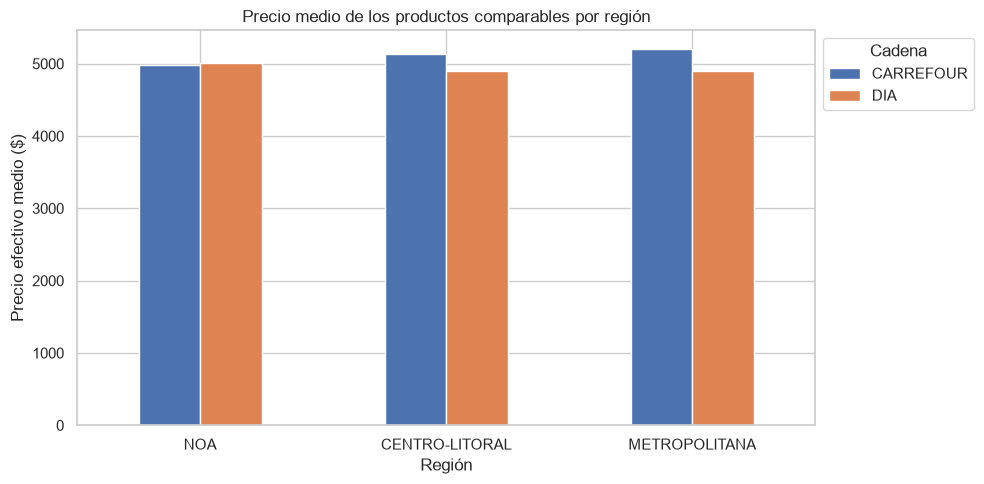

In [40]:
# Gráfico 1: precio medio regional por cadena
tabla_grafico = ranking_regional.pivot(
    index='region',
    columns='cadena',
    values='precio_medio_region'
)

orden_regiones = tabla_grafico.mean(axis=1).sort_values().index
tabla_grafico = tabla_grafico.loc[orden_regiones]

fig, ax = plt.subplots(figsize=(10, 5))
tabla_grafico.plot(kind='bar', ax=ax)
ax.set_title('Precio medio de los productos comparables por región')
ax.set_xlabel('Región')
ax.set_ylabel('Precio efectivo medio ($)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Cadena', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


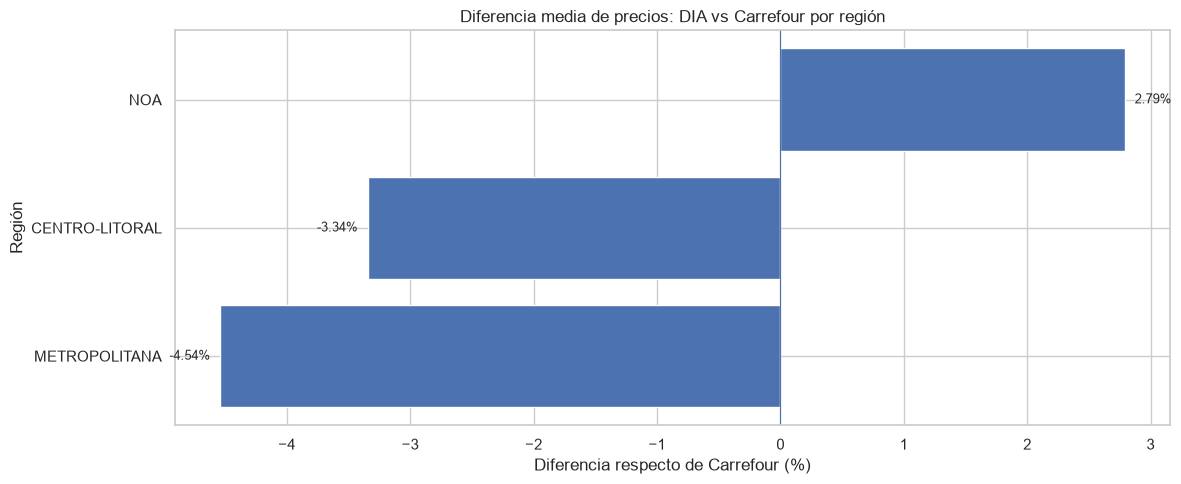

In [41]:
# Gráfico 2: diferencia DIA vs Carrefour por región
datos = resumen_regional.sort_values('diferencia_media_pct')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(datos.index, datos['diferencia_media_pct'])
ax.axvline(0, linewidth=0.8)
ax.set_title('Diferencia media de precios: DIA vs Carrefour por región')
ax.set_xlabel('Diferencia respecto de Carrefour (%)')
ax.set_ylabel('Región')

for i, v in enumerate(datos['diferencia_media_pct']):
    ax.text(
        v + (0.08 if v >= 0 else -0.08),
        i,
        f'{v:.2f}%',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.show()


El gráfico muestra la diferencia porcentual promedio entre DIA y Carrefour dentro de cada región. Para cada producto se calcula la diferencia relativa respecto del precio regional de Carrefour y luego se promedia dentro de la región. Valores negativos indican que DIA es más barato; valores positivos, que Carrefour lo es. Así, Metropolitana y Centro–Litoral presentan una ventaja promedio para DIA, mientras que en el NOA la diferencia favorece a Carrefour. Este indicador permite comparar regiones sin que los niveles absolutos de precios distorsionen la interpretación.


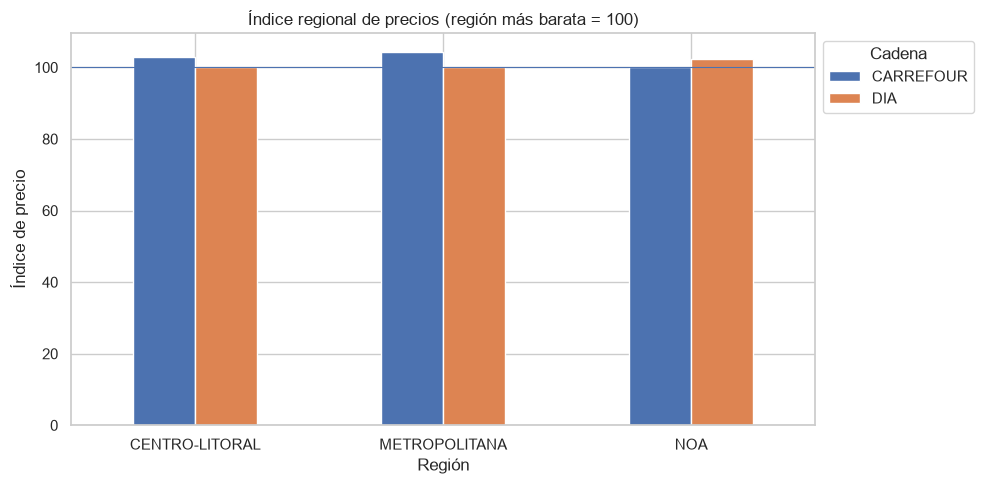

In [42]:
# Gráfico 3: índice de precios respecto de la región más barata de cada cadena
tabla_indice = ranking_regional.pivot(
    index='region',
    columns='cadena',
    values='indice_vs_region_mas_barata'
)

fig, ax = plt.subplots(figsize=(10, 5))
tabla_indice.plot(kind='bar', ax=ax)
ax.axhline(100, linewidth=0.8)
ax.set_title('Índice regional de precios (región más barata = 100)')
ax.set_xlabel('Región')
ax.set_ylabel('Índice de precio')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Cadena', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


### 10.2 Lectura del análisis regional

El análisis regional permite observar simultáneamente dos dimensiones: el **nivel de precios entre zonas** y la **brecha entre DIA y Carrefour dentro de cada zona**.

La interpretación debe hacerse sobre el universo común de productos y teniendo presente que las regiones no tienen la misma cantidad de provincias. Por eso se da el mismo peso a cada provincia al construir el precio regional.

Este análisis complementa, pero no reemplaza, el análisis provincial: una diferencia regional puede ocultar comportamientos distintos entre las provincias que la componen.


## 11. Visualizaciones principales

Se priorizan gráficos que puedan interpretarse rápidamente y respondan directamente a las preguntas de la etapa.


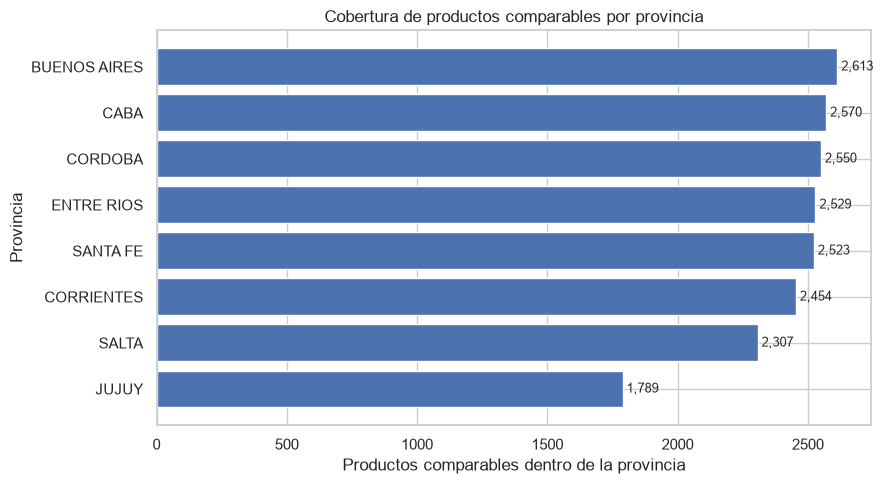

In [43]:
# Cobertura de productos comparables por provincia.
# Se utiliza la exploración inicial realizada en la sección 4,
# antes de exigir cobertura completa en todas las provincias.

cobertura_por_provincia = (
    pares_limpios
    .groupby('provincia')['id_producto']
    .nunique()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    cobertura_por_provincia.index,
    cobertura_por_provincia.values
)

ax.set_xlabel('Productos comparables dentro de la provincia')
ax.set_ylabel('Provincia')
ax.set_title('Cobertura de productos comparables por provincia')

for i, v in enumerate(cobertura_por_provincia.values):
    ax.text(
        v + 15,
        i,
        f'{v:,}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

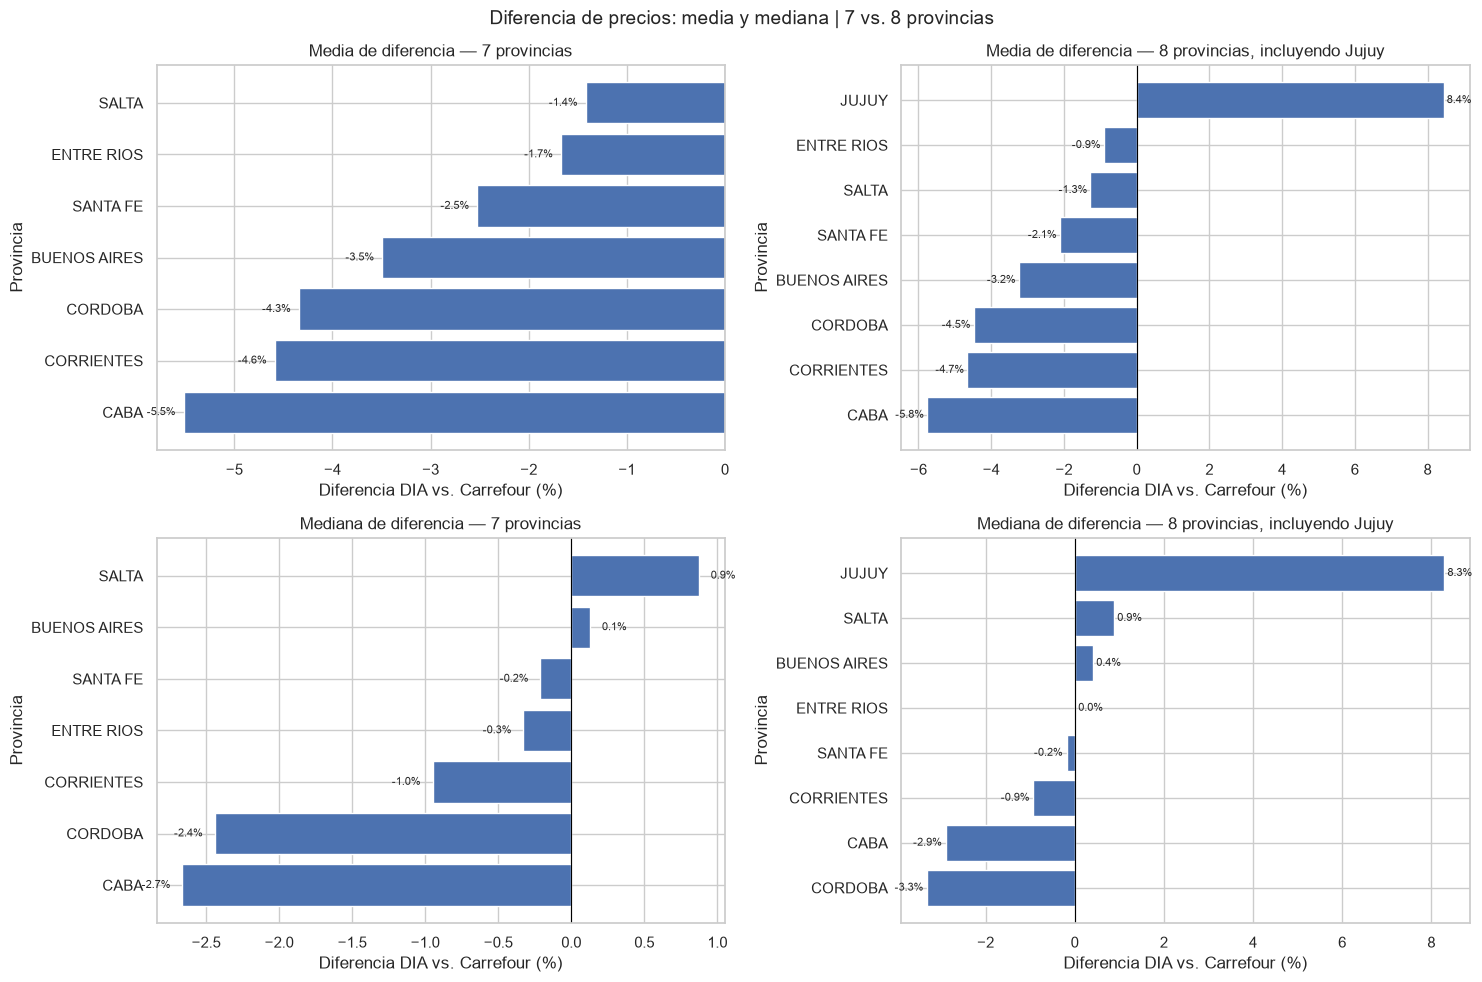

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, (resumen, titulo) in enumerate([
    (resumen_diferencias_7, '7 provincias'),
    (resumen_diferencias_8, '8 provincias, incluyendo Jujuy')
]):
    for row, medida in enumerate(['media_diferencia_pct', 'mediana_diferencia_pct']):
        
        datos = resumen.sort_values(medida)
        axes[row, col].barh(datos.index, datos[medida])
        axes[row, col].axvline(0, color='black', linewidth=0.8)
        
        nombre = 'Mediana' if 'mediana' in medida else 'Media'
        
        axes[row, col].set_title(f'{nombre} de diferencia — {titulo}')
        axes[row, col].set_xlabel('Diferencia DIA vs. Carrefour (%)')
        axes[row, col].set_ylabel('Provincia')

        for i, v in enumerate(datos[medida]):
            axes[row, col].text(
                v + (0.08 if v >= 0 else -0.08),
                i,
                f'{v:.1f}%',
                va='center',
                ha='left' if v >= 0 else 'right',
                fontsize=8
            )

plt.suptitle('Diferencia de precios: media y mediana | 7 vs. 8 provincias', fontsize=14)
plt.tight_layout()
plt.show()


El gráfico compara la diferencia porcentual entre DIA y Carrefour por provincia, mostrando tanto la media como la mediana para los universos de 7 y 8 provincias. La media captura el efecto promedio, mientras que la mediana refleja la diferencia típica sin influencia de valores extremos. Diferenciar fila superior/inferior permite distinguir claramente ambas medidas: la fila superior corresponde a la media y la inferior a la mediana. Esto facilita evaluar la consistencia territorial de las diferencias de precios y el impacto de incluir Jujuy en el análisis.


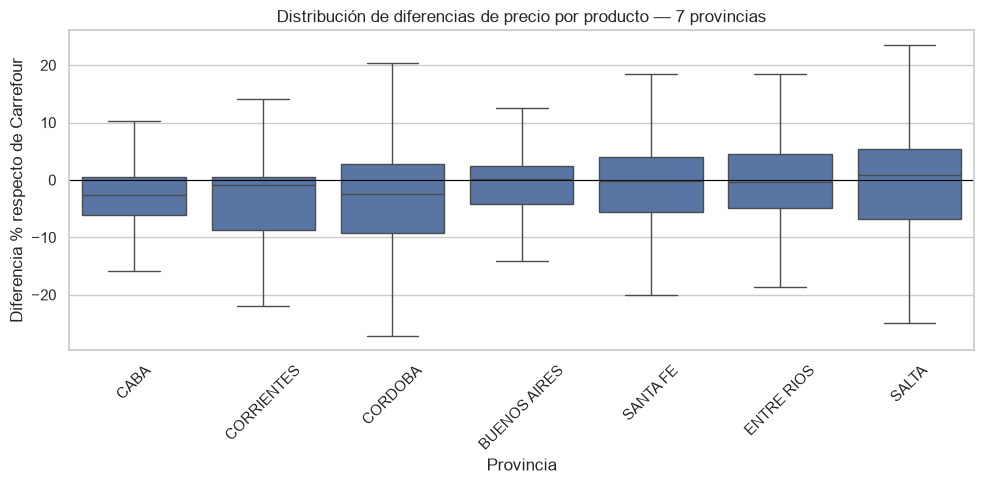

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

# Orden de provincias según la media de diferencia
orden = resumen_diferencias_7.sort_values('media_diferencia_pct').index

# Boxplot de diferencias por provincia
sns.boxplot(
    data=comparacion_7,
    x='provincia',
    y='diferencia_pct',
    order=orden,
    showfliers=False,
    ax=ax
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Provincia')
ax.set_ylabel('Diferencia % respecto de Carrefour')
ax.set_title('Distribución de diferencias de precio por producto — 7 provincias')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


El boxplot muestra la distribución de la diferencia porcentual por producto entre DIA y Carrefour en las 7 provincias. CABA, Córdoba y Corrientes presentan distribuciones claramente negativas, indicando que DIA es sistemáticamente más barato en esos territorios. Buenos Aires, Santa Fe y Entre Ríos exhiben diferencias cercanas a cero, con una ventaja leve para DIA pero sin una brecha marcada. En Salta la distribución se ubica levemente por encima de cero, reflejando que Carrefour tiende a ser más barato en esa provincia. Este gráfico complementa las medias y medianas provinciales mostrando la variabilidad interna de cada territorio y la consistencia de las diferencias de precios.



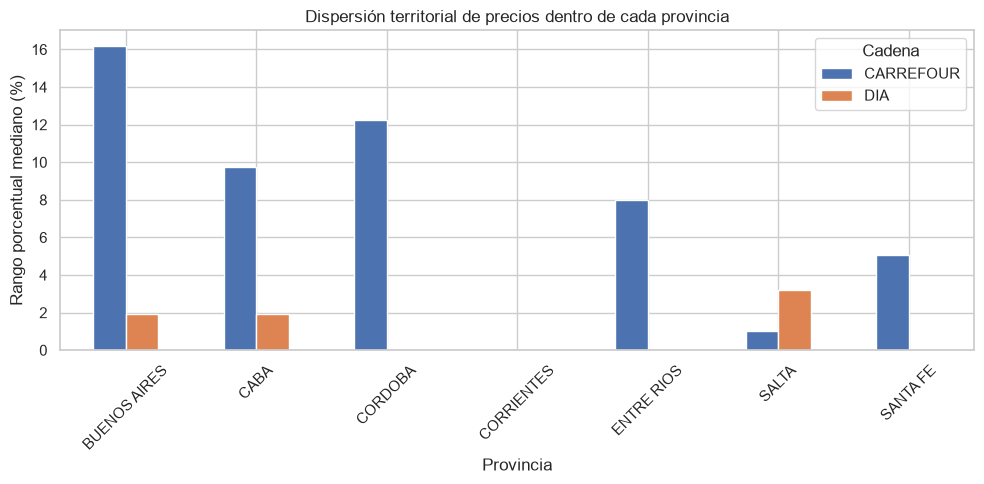

In [46]:
# Pivot de la dispersión territorial por provincia y cadena
pivot_disp = (
    resumen_dispersion_prov
    .pivot(index='provincia', columns='cadena', values='rango_pct_mediano')
)
fig, ax = plt.subplots(figsize=(10, 5))
pivot_disp.plot(kind='bar', ax=ax)

ax.set_title('Dispersión territorial de precios dentro de cada provincia')
ax.set_xlabel('Provincia')
ax.set_ylabel('Rango porcentual mediano (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Cadena')
plt.tight_layout()
plt.show()


El gráfico muestra la dispersión territorial interna de precios entre sucursales dentro de cada provincia, medida como el rango porcentual mediano. Carrefour exhibe una dispersión elevada en Buenos Aires, Córdoba y CABA, y también en Entre Ríos y Santa Fe, donde sus valores superan con claridad el 5%, reflejando una estructura de precios más heterogénea dentro de cada provincia. En contraste, DIA mantiene una dispersión prácticamente nula en la mayoría de los territorios: Córdoba, Corrientes, Entre Ríos y Santa Fe presentan valores de 0%, y Corrientes incluso muestra ausencia total de dispersión en ambas cadenas. La única excepción relevante para DIA es Salta, donde su variabilidad interna supera a la de Carrefour. En conjunto, el patrón confirma que Carrefour opera con una estructura territorial más dispersa, mientras que DIA mantiene precios mucho más homogéneos entre sucursales, salvo en casos puntuales como Salta.


## 12. Hallazgos y lectura de resultados

### 12.1 Construcción del universo comparable

La exploración inicial identificó **19.368 pares producto–provincia** con información comparable entre DIA y Carrefour dentro de las ocho provincias analizadas.

Antes de construir los universos definitivos se realizó una revisión de diferencias porcentuales extremas. Se detectaron **33 pares producto–provincia** con `|diferencia_pct| > 500%`, correspondientes a **5 productos**. Estos productos fueron excluidos del análisis posterior para evitar que diferencias relativas excepcionalmente grandes tuvieran una influencia desproporcionada sobre los indicadores agregados.

Luego de este filtro se construyeron dos universos de comparación:

- **8 provincias:** 1.662 productos con cobertura completa.
- **7 provincias sin Jujuy:** 2.220 productos con cobertura completa.

El universo de 7 provincias incorpora **558 productos adicionales**, equivalentes a un **33,57% más** respecto del universo de 8 provincias.

Por esta razón, el universo de **7 provincias se adopta como análisis principal**, mientras que el de 8 provincias se conserva como análisis complementario de sensibilidad. La exclusión de Jujuy responde principalmente a la cobertura limitada de Carrefour observada en esa provincia y no implica afirmar que sus precios sean incorrectos o poco representativos en términos generales.

---

### 12.2 Lectura integrada de los resultados del universo flexible y del universo homogéneo

La etapa territorial presenta dos lecturas complementarias que no deben confundirse:

1. **Nivel absoluto de precios por provincia** (punto 7 y 7.1): compara el nivel medio de cada cadena dentro de cada provincia usando el universo flexible.
2. **Diferencia relativa entre cadenas** (punto 8 y 12.2): compara DIA vs Carrefour producto por producto dentro del universo homogéneo.

Estas dos perspectivas responden preguntas distintas. El punto 7 y 7.1 muestran dónde cada cadena es más o menos cara en términos absolutos; el punto 8 y 12.2 muestran si, dentro de un producto concreto, DIA o Carrefour resulta más barato.

En el universo flexible de 8 provincias, el punto 7.1 muestra que **DIA presenta un precio medio inferior al de Carrefour en 7 de las 8 provincias**:

| Provincia | DIA | Carrefour | Diferencia |
|---|---:|---:|---:|
| Corrientes | $5.154,72 | $5.505,02 | **-6,36%** |
| CABA | $5.125,34 | $5.493,11 | **-6,70%** |
| Córdoba | $5.122,80 | $5.428,62 | **-5,63%** |
| Buenos Aires | $5.090,94 | $5.362,60 | **-5,07%** |
| Santa Fe | $5.138,23 | $5.389,65 | **-4,66%** |
| Entre Ríos | $5.103,19 | $5.284,00 | **-3,42%** |
| Salta | $5.187,37 | $5.359,54 | **-3,21%** |
| Jujuy | $4.991,47 | $4.759,10 | **+4,88%** |

El signo negativo indica que DIA es más barato en términos medios dentro de la provincia; el positivo indica lo contrario. Por ello, **Jujuy es la única provincia del universo flexible en la que Carrefour resulta más barato que DIA**.

Sin embargo, este resultado no debe leerse como un indicador de que Jujuy sea la provincia 'más barata' en una comparación de cadenas. El punto 7.1 también muestra que **Jujuy es la provincia con el menor nivel de precios absoluto para ambas cadenas** dentro del universo flexible:

- **DIA:** Jujuy = **$4.991,47** (mínimo)
- **Carrefour:** Jujuy = **$4.759,10** (mínimo)

Esto es clave para la interpretación final: **el ranking provincial por nivel absoluto y la comparación directa entre cadenas son dos cosas distintas**. Jujuy puede ser la provincia más barata en nivel absoluto para ambas cadenas y, aun así, mostrar una diferencia relativa favorable para Carrefour dentro de esa provincia.

---

### 12.3 Diferencias de precios entre DIA y Carrefour por provincia (universo homogéneo)

La comparación principal se realiza producto contra producto dentro de cada provincia. Para cada combinación `provincia + id_producto` se calcula el precio medio observado en cada cadena y posteriormente la diferencia porcentual:

`diferencia_pct = (precio_DIA - precio_Carrefour) / precio_Carrefour * 100`

Con esta definición:

- valores negativos indican que **DIA presenta un precio menor**;
- valores positivos indican que **Carrefour presenta un precio menor**.

En el universo principal de 7 provincias, la media de las diferencias porcentuales es negativa en todas las provincias:

- **CABA:** -5,52%
- **Corrientes:** -4,59%
- **Córdoba:** -4,34%
- **Buenos Aires:** -3,49%
- **Santa Fe:** -2,52%
- **Entre Ríos:** -1,67%
- **Salta:** -1,42%

Por lo tanto, dentro del universo homogéneo definido para esta etapa, **DIA presenta una diferencia media de precio favorable frente a Carrefour en las siete provincias analizadas**.

La proporción de productos en los que DIA presenta un precio menor también varía según el territorio:

- Corrientes: **61,26%**
- CABA: **60,59%**
- Córdoba: **59,46%**
- Santa Fe: **53,20%**
- Entre Ríos: **52,66%**
- Buenos Aires: **47,48%**
- Salta: **44,68%**

Esto muestra que la ventaja media de DIA no tiene la misma intensidad ni la misma frecuencia en todas las provincias.

---

### 12.4 Media y mediana: dos lecturas complementarias

La **media** se mantiene como medida principal del proyecto, mientras que la **mediana** se utiliza como indicador complementario de robustez.

En el universo de 7 provincias, las medianas de las diferencias porcentuales son:

- CABA: **-2,66%**
- Córdoba: **-2,44%**
- Corrientes: **-0,95%**
- Entre Ríos: **-0,33%**
- Santa Fe: **-0,21%**
- Buenos Aires: **+0,13%**
- Salta: **+0,88%**

La diferencia entre media y mediana resulta relevante. La media presenta una diferencia favorable a DIA en las siete provincias, mientras que la mediana es mucho más cercana a cero y llega a ser ligeramente positiva en Buenos Aires y Salta.

Esto indica que la ventaja observada mediante la media **no es uniforme a lo largo de toda la distribución de productos** y que algunas diferencias porcentuales de mayor magnitud influyen sobre el promedio.

Por ello, la conclusión debe formularse en términos de **diferencia media del universo comparable**, evitando interpretar la media como una ventaja generalizada para todos los productos.

---

### 12.5 Sensibilidad al incluir Jujuy

El análisis de sensibilidad con las ocho provincias muestra un comportamiento territorial claramente diferente en Jujuy.

En el universo homogéneo de 8 provincias:

- diferencia media en Jujuy: **+8,45%**
- diferencia mediana: **+8,28%**
- DIA es más barato en **26,84%** de los productos
- Carrefour es más barato en **70,04%** de los productos

El signo positivo indica que, dentro de este universo, **Carrefour presenta precios inferiores a DIA en Jujuy**.

Este comportamiento contrasta con el resto de las provincias y muestra que la incorporación de Jujuy modifica de manera significativa la lectura territorial general.

La clave metodológica es que este resultado **no contradice** lo observado en el punto 7.1. En el universo flexible, Jujuy tiene el menor nivel absoluto de precios para ambas cadenas, pero al comparar cadenas de manera relativa dentro de ese mismo territorio **Carrefour resulta más barato**. En otras palabras, **la provincia puede ser la más barata en valor absoluto y aun así mostrar una ventaja relativa para Carrefour**.

Por este motivo, el universo de 8 provincias se conserva como **análisis de sensibilidad**, mientras que el de 7 provincias se utiliza como referencia principal para la comparación relativa entre cadenas.

---

### 12.6 Ranking provincial por nivel absoluto y por diferencia relativa

El punto 7.1 construye un ranking provincial por cadena utilizando el universo flexible de 8 provincias. El objetivo es comparar el **nivel medio de precios** de cada cadena por provincia, no la ventaja relativa entre cadenas dentro de cada provincia.

En el universo flexible, el ranking absoluto por cadena es:

- **DIA (menor a mayor precio medio):** Jujuy, Buenos Aires, Entre Ríos, Córdoba, CABA, Santa Fe, Corrientes, Salta.
- **Carrefour (menor a mayor precio medio):** Jujuy, Entre Ríos, Salta, Buenos Aires, Santa Fe, Córdoba, CABA, Corrientes.

La lectura relevante es que **Jujuy ocupa el primer lugar en ambas cadenas**, es decir, presenta el menor precio medio absoluto para DIA y para Carrefour, pero esto no implica que DIA sea más barata allí. La comparación entre cadenas en Jujuy se invierte en el universo homogéneo, donde Carrefour es más barato.

Esto refuerza la necesidad de separar con claridad dos preguntas conceptualmente distintas:

1. **¿Qué provincia tiene un nivel medio de precios más bajo?** (punto 7 y 7.1)
2. **¿Qué cadena es más barata dentro de una provincia?** (punto 8 y 12.3)

La respuesta a una y otra puede diferir, y esa diferencia es justamente parte del análisis territorial de la Etapa 3.

---

### 12.7 Diferencias territoriales de los mismos productos

Además de comparar las cadenas entre sí, se analizó cómo cambia el precio de un mismo producto entre las distintas provincias.

Para cada producto se calculó el rango porcentual entre su precio provincial máximo y mínimo:

`rango_pct = (máximo - mínimo) / máximo * 100`

La **mediana del rango porcentual** fue:

- **Carrefour: 9,21%**
- **DIA: 3,61%**

El resultado indica que, dentro del universo de 2.220 productos comparables en las siete provincias, los precios de Carrefour presentan una **mayor dispersión territorial** para un mismo producto.

En términos descriptivos, los precios de DIA muestran una estructura más homogénea entre provincias, mientras que Carrefour presenta mayores diferencias territoriales.

Este indicador mide dispersión y no permite determinar por sí solo las causas de esas diferencias.

---

### 12.8 Dispersión entre sucursales dentro de cada provincia

También se analizó una segunda dimensión de variabilidad: la diferencia de precios entre sucursales de una misma cadena dentro de cada provincia.

El rango porcentual mediano de Carrefour fue:

- Buenos Aires: **16,20%**
- Córdoba: **12,27%**
- CABA: **9,73%**
- Entre Ríos: **7,96%**
- Santa Fe: **5,07%**
- Salta: **0,99%**
- Corrientes: **0%**

Para DIA se obtuvo:

- Salta: **3,20%**
- Buenos Aires: **1,95%**
- CABA: **1,95%**
- Córdoba: **0%**
- Corrientes: **0%**
- Entre Ríos: **0%**
- Santa Fe: **0%**

El patrón general muestra una **mayor dispersión interna en Carrefour** en varias provincias, mientras que DIA presenta valores más reducidos en la mayoría de los territorios.

No obstante, estos resultados deben interpretarse junto con la cantidad de sucursales disponibles. Por ejemplo, dentro del universo de 7 provincias existen solo **3 sucursales de DIA en Córdoba** y **2 sucursales de Carrefour en Corrientes**. Por lo tanto, un rango de 0% en una provincia con pocas sucursales no demuestra ausencia general de variabilidad.

La dispersión entre sucursales y la dispersión entre provincias representan dimensiones diferentes y deben mantenerse conceptualmente separadas.

---

### 12.9 Comportamiento de precios por región

Como complemento del análisis provincial se agruparon las ocho provincias en tres regiones:

- **METROPOLITANA:** Buenos Aires y CABA
- **CENTRO–LITORAL:** Córdoba, Santa Fe, Entre Ríos y Corrientes
- **NOA:** Jujuy y Salta

El análisis regional se realizó utilizando el universo homogéneo de **1.662 productos con cobertura completa en las ocho provincias**.

Para evitar que una región tenga mayor peso simplemente por contar con más provincias, primero se calculó el precio medio de cada producto dentro de cada provincia y luego se promediaron las provincias pertenecientes a cada región. De esta manera, cada provincia tiene el mismo peso dentro de su región.

Los resultados fueron:

| Región | Precio medio DIA | Precio medio Carrefour | Diferencia media |
|---|---:|---:|---:|
| CENTRO–LITORAL | $4.895,57 | $5.136,69 | **-3,34%** |
| METROPOLITANA | $4.898,10 | $5.199,96 | **-4,54%** |
| NOA | $5.012,32 | $4.985,51 | **+2,79%** |

En **METROPOLITANA** y **CENTRO–LITORAL**, DIA presenta precios medios regionales inferiores a Carrefour.

En **NOA** ocurre lo contrario: Carrefour presenta un precio medio regional ligeramente inferior a DIA.

La proporción de productos donde DIA resulta más barato también muestra diferencias regionales:

- METROPOLITANA: **58,12%**
- CENTRO–LITORAL: **55,05%**
- NOA: **30,93%**

En consecuencia, el comportamiento territorial observado a nivel provincial también se refleja a escala regional: **DIA presenta una ventaja relativa en Metropolitana y Centro–Litoral, mientras que Carrefour presenta una ventaja en NOA**.

---

### 12.10 Lectura integrada de los resultados

Los resultados de la Etapa 3 permiten identificar varios patrones complementarios:

1. **DIA presenta una diferencia media de precio favorable en las siete provincias del universo principal**, aunque la magnitud de esa diferencia varía territorialmente.

2. **La ventaja media de DIA no es uniforme en todos los productos**. La mediana es más cercana a cero y resulta ligeramente favorable a Carrefour en Buenos Aires y Salta.

3. **Jujuy presenta un comportamiento diferencial**. En el universo flexible es la provincia con el menor nivel absoluto de precios para ambas cadenas, pero en el universo homogéneo resulta favorable a Carrefour. Este resultado refuerza la necesidad de distinguir entre nivel absoluto y diferencia relativa.

4. **Carrefour presenta mayor dispersión territorial de los mismos productos**: el rango porcentual mediano entre provincias es 9,21%, frente al 3,61% de DIA.

5. **La dispersión entre sucursales también es generalmente mayor en Carrefour**, aunque este resultado debe interpretarse teniendo en cuenta la cantidad desigual de sucursales disponibles por provincia.

6. **El comportamiento regional no es uniforme**. DIA presenta precios medios inferiores a Carrefour en Metropolitana y Centro–Litoral, mientras que Carrefour presenta precios medios inferiores en NOA.

7. **Los casos con diferencias superiores al 500% se concentran en solo 5 productos**, lo que permitió controlar su influencia antes de construir los universos definitivos.

En conjunto, los resultados muestran que las diferencias de precios entre DIA y Carrefour **dependen del territorio y de la escala de análisis**. La comparación entre cadenas, la dispersión entre provincias y la dispersión entre sucursales aportan información diferente y complementaria sobre la estructura territorial de precios. La lectura correcta de la Etapa 3 no debe mezclar el ranking del nivel absoluto (punto 7 y 7.1) con la comparación relativa entre cadenas (punto 8 y 12.3): ambas son válidas, pero responden a preguntas distintas y deben interpretarse en conjunto.


## 13. Limitaciones del análisis

Los resultados de esta etapa deben interpretarse considerando las siguientes limitaciones:

- El análisis corresponde exclusivamente a **julio de 2026**, por lo que representa una fotografía temporal y no permite determinar tendencias de largo plazo.

- El universo principal está compuesto por **7 provincias**, excluyendo Jujuy debido a la cobertura limitada de Carrefour. Se conserva el universo de 8 provincias como análisis de sensibilidad.

- La cantidad de sucursales es desigual entre cadenas y provincias. Esto afecta la cantidad de observaciones disponibles y debe considerarse especialmente al interpretar medidas de dispersión.

- La comparación principal se realiza **producto contra producto dentro de cada provincia**, utilizando el precio medio por producto y provincia. No se utiliza como medida principal un promedio directo de todas las observaciones de sucursal.

- La **media** es la medida principal definida para el proyecto, mientras que la mediana se utiliza como referencia complementaria para evaluar la robustez de los resultados.

- `diferencia_pct` utiliza el precio de Carrefour como denominador. Por lo tanto, diferencias absolutas pequeñas pueden generar diferencias porcentuales elevadas cuando el precio de Carrefour es particularmente bajo.

- Se excluyeron **5 productos** que presentaron al menos un caso con `|diferencia_pct| > 500%`. Esta decisión reduce la influencia de observaciones extremas, pero también implica eliminar esos productos del universo posterior.

- La exclusión de dichos productos no demuestra que los valores originales sean incorrectos. El criterio constituye una decisión metodológica de control de valores extremos para esta etapa.

- La dispersión territorial entre provincias y la dispersión entre sucursales dentro de una provincia son indicadores diferentes y no deben interpretarse como equivalentes.

- Los valores de dispersión nulos en provincias con pocas sucursales no permiten concluir que una cadena mantenga precios idénticos en todo el territorio.

- El análisis regional otorga el mismo peso a cada provincia dentro de una región. Por lo tanto, no representa participación de mercado, cantidad de sucursales, población, volumen de ventas ni peso económico de cada provincia.

- Los precios medios regionales tampoco representan el precio de una canasta de consumo ponderada por cantidades compradas. Cada producto comparable tiene el mismo peso dentro del cálculo agregado.

- No se repite en esta etapa el análisis detallado de promociones realizado anteriormente. La comparación utiliza el `precio_efectivo` construido en etapas previas.

- Las diferencias observadas son **descriptivas**. El análisis no permite establecer causalidad ni determinar si las diferencias responden a costos logísticos, competencia local, políticas comerciales, estructura de sucursales, promociones u otros factores.

- Los resultados no deben extrapolarse automáticamente a otras fechas, provincias no incluidas o al conjunto completo de productos comercializados por ambas cadenas.


## 14. Conclusión de la Etapa 3

La Etapa 3 incorpora la dimensión territorial al análisis comparativo entre DIA y Carrefour y establece un universo de productos suficientemente controlado para continuar con las etapas de categorización y análisis posteriores.

El proceso comenzó con **19.368 pares producto–provincia comparables** entre las dos cadenas. La revisión de valores extremos identificó **33 pares correspondientes a 5 productos** con diferencias porcentuales superiores al 500%. Estos productos fueron excluidos del análisis posterior para reducir la influencia de diferencias relativas excepcionalmente grandes.

A partir del universo depurado se construyeron dos referencias:

- **2.220 productos con cobertura completa en 7 provincias**, utilizado como universo principal;
- **1.662 productos con cobertura completa en 8 provincias**, utilizado como análisis complementario de sensibilidad.

El universo de 7 provincias permite incorporar **558 productos adicionales**, equivalentes a un **33,57% más** que el universo de 8 provincias, y evita que la cobertura limitada de Carrefour en Jujuy condicione la comparación principal.

Dentro de las siete provincias, la **media de la diferencia porcentual es negativa en todos los casos**, lo que indica una ventaja media de DIA frente a Carrefour dentro del universo comparable. La mayor diferencia media favorable a DIA se observa en **CABA (−5,52%)**, mientras que la menor se registra en **Salta (−1,42%)**.

Sin embargo, la comparación entre media y mediana demuestra que esta ventaja no es uniforme. En **Buenos Aires y Salta**, la mediana de la diferencia es ligeramente positiva, por lo que los resultados deben interpretarse como diferencias promedio del universo analizado y no como una superioridad generalizada de una cadena en todos los productos.

El análisis territorial de los mismos productos aporta otro resultado relevante: **Carrefour presenta una dispersión entre provincias mayor que DIA**, con un rango porcentual mediano de **9,21% frente a 3,61%**. La dispersión entre sucursales dentro de las provincias también resulta generalmente mayor en Carrefour, aunque esta comparación está condicionada por la cobertura desigual de sucursales.

El análisis regional muestra además que la relación entre cadenas cambia según el territorio. **DIA presenta precios medios inferiores a Carrefour en Metropolitana y Centro–Litoral**, mientras que **Carrefour presenta un precio medio inferior en NOA**. Este resultado confirma que la dimensión geográfica aporta información que no puede observarse mediante una comparación agregada de ambas cadenas.

En consecuencia, la principal conclusión de esta etapa no es simplemente determinar qué cadena es más barata, sino demostrar que **la relación de precios entre DIA y Carrefour presenta una dimensión territorial significativa**. La cadena con menor precio relativo depende del territorio y del nivel de agregación utilizado, mientras que la dispersión de precios también difiere entre cadenas.

Como resultado final, la Etapa 3 deja dos estructuras complementarias para las siguientes etapas:

- datasets de observaciones **producto × sucursal × provincia × cadena**, que conservan la granularidad necesaria para análisis posteriores;
- tablas agregadas **producto × provincia × cadena**, con precio medio, mediana y cantidad de sucursales, que permiten realizar comparaciones territoriales homogéneas.

Esta estructura permite avanzar a la **Etapa 4**, donde se podrá construir una categorización de productos, manteniendo la trazabilidad entre los productos originales y las observaciones territoriales utilizadas durante el análisis.